findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight normal for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.


✅ Зарегистрированы шрифты: ['Gilroy', 'Gilroy']
🎯 Основной шрифт: Gilroy
🎨 Палитра: {'розовый': '#FB52A5', 'оранжевый': '#FD8616', 'фиолетовый': '#7061F0'}
Готово — все следующие графики автоматически используют шрифт и палитру.


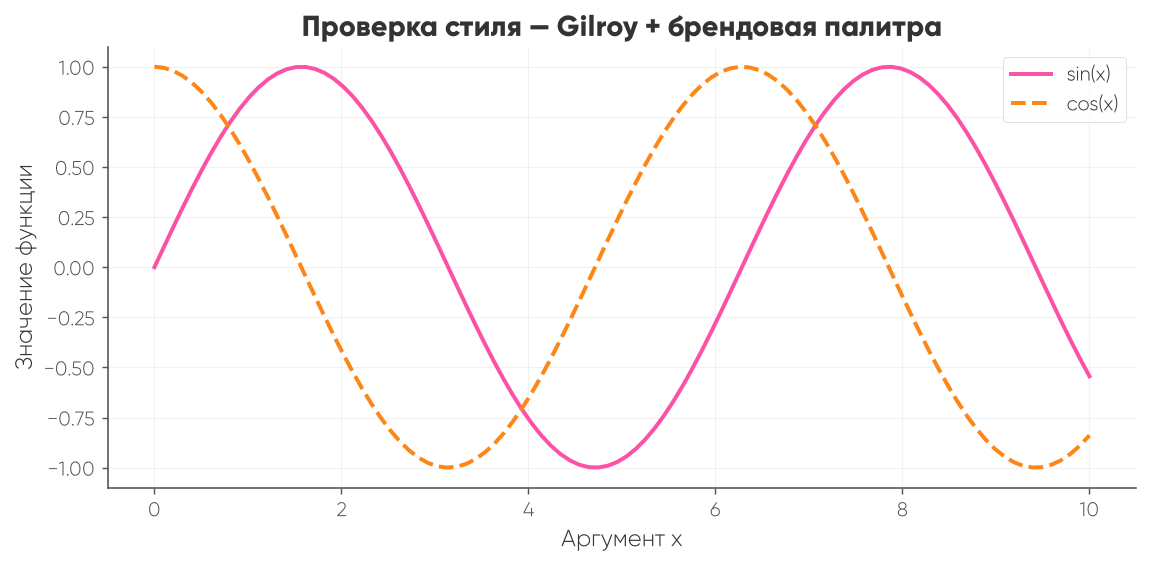

In [1]:
# %% [markdown]
# ## ✨ Глобальный дизайн графиков — шрифт Gilroy + фирменная палитра

# %%
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# --------------------------
# 1. Регистрация шрифтов Gilroy
# --------------------------
font_dir = Path.cwd()
font_files = [
    font_dir / "Gilroy-Light.otf",
    font_dir / "Gilroy-ExtraBold.otf",
]

missing_fonts = [str(f) for f in font_files if not f.exists()]
if missing_fonts:
    raise FileNotFoundError(f"Шрифты Gilroy не найдены в корне проекта: {missing_fonts}")

registered_names = []
for font_file in font_files:
    font_manager.fontManager.addfont(str(font_file))
    registered_names.append(font_manager.FontProperties(fname=str(font_file)).get_name())

_gilroy_name = registered_names[0]
print("✅ Зарегистрированы шрифты:", registered_names)
print("🎯 Основной шрифт:", _gilroy_name)

# --------------------------
# 2. Фирменная палитра
# --------------------------
PINK   = '#FB52A5'
ORANGE = '#FD8616'
PURPLE = '#7061F0'
WHITE  = '#FFFFFF'
INK    = '#333333'   # текст
MUTE   = '#555555'   # оси/тики
GREY   = '#B0B0B0'   # нейтральный/контрольная группа

BRAND = [PINK, ORANGE, PURPLE]                 # основной циклический порядок цветов
BRAND_EXT = [PINK, ORANGE, PURPLE, INK, GREY]  # если серий больше трёх

# диверг. цветовая карта для heatmap/корреляций на основе фирменных цветов
BRAND_CMAP = LinearSegmentedColormap.from_list('brand_diverging', [PURPLE, WHITE, PINK])
# последовательная карта (например, для интенсивности/плотности)
BRAND_SEQ = LinearSegmentedColormap.from_list('brand_sequential', [WHITE, ORANGE, PINK])

# --------------------------
# 3. Глобальные rcParams
# --------------------------
plt.rcParams.update({
    # шрифт
    'font.family': _gilroy_name,
    'font.weight': 'regular',

    # размеры
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 18,
    'figure.dpi': 130,

    # фон — всегда белый, независимо от темы ноутбука/системы
    'figure.facecolor': WHITE,
    'axes.facecolor': WHITE,
    'savefig.facecolor': WHITE,

    # текст и оси
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTE,
    'ytick.color': MUTE,
    'axes.edgecolor': MUTE,

    # цикл цветов по умолчанию — подтянется в любой plot()/bar()/scatter() без явного цвета
    'axes.prop_cycle': plt.cycler(color=BRAND_EXT),

    # сетка и рамки
    'axes.grid': True,
    'grid.color': '#E8E8E8',
    'grid.alpha': 0.6,
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.9,

    # линии/маркеры по умолчанию
    'lines.linewidth': 2.2,
    'lines.markersize': 6,
    'patch.edgecolor': WHITE,
    'patch.linewidth': 0.4,
})

matplotlib.rc('font', family=_gilroy_name)

print("🎨 Палитра:", {'розовый': PINK, 'оранжевый': ORANGE, 'фиолетовый': PURPLE})
print("Готово — все следующие графики автоматически используют шрифт и палитру.")

# --------------------------
# 4. Тестовый график (проверка стиля)
# --------------------------
x = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)', linestyle='--')
ax.set_title('Проверка стиля — Gilroy + брендовая палитра')
ax.set_xlabel('Аргумент x'); ax.set_ylabel('Значение функции')
ax.legend()
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import pandas as pd
import numpy as np
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})

UP  = 'uploads/'
OUT = 'outputs/'

# Расшифровка КЛАДР из условия задачи
KLADR = {77: 'Москва', 50: 'Московская область', 78: 'Санкт-Петербург', 16: 'Республика Татарстан',
         66: 'Свердловская область', 54: 'Новосибирская область', 47: 'Ленинградская область',
         52: 'Нижегородская область', 23: 'Краснодарский край', 63: 'Самарская область',
         74: 'Челябинская область', 42: 'Кемеровская область', 72: 'Тюменская область',
         2: 'Республика Башкортостан', 24: 'Красноярский край', 55: 'Омская область'}

WIN_START, WIN_END = '2026-04-01', '2026-08-31'   # рабочее окно
CRISIS_MONTHS = [6, 7, 8]                          # период кризиса

In [3]:
clients = pd.read_csv(UP + 'clients_demographics_clean.csv', sep=';', decimal=',')
fines   = pd.read_csv(UP + 'fines_2026_clean.csv',              sep=';', decimal=',')
fuel    = pd.read_csv(UP + 'fuel_transaction_clean.csv',        sep=';', decimal=',')

fines['fine_date']     = pd.to_datetime(fines.fine_date)          # было bill_offence_date
fuel['order_datetime'] = pd.to_datetime(fuel.order_datetime)
clients['sub_date']    = pd.to_datetime(clients.subscription_creation_date)

print('Таблица 1 — клиенты/авто :', clients.shape)
print('Таблица 2 — штрафы 2026  :', fines.shape)
print('Таблица 3 — заправки     :', fuel.shape)

Таблица 1 — клиенты/авто : (21068, 21)
Таблица 2 — штрафы 2026  : (56010, 7)
Таблица 3 — заправки     : (282694, 5)


## Чистка

In [4]:
# создаём engine_hp, если её ещё нет в clients
clients['engine_hp'] = pd.to_numeric(clients.engine_type.fillna('').str.extract(r'\(([\d.]+)')[0], errors='coerce')

# ================== ШАГ 1: убираем клиентов с 2+ машинами сразу ==================
n_autos = clients.groupby('client_id').auto_document_id.nunique().rename('n_autos')
single_ids = n_autos[n_autos == 1].index

print('всего клиентов:', n_autos.shape[0])
print('с одной машиной (оставляем):', len(single_ids), f'({len(single_ids)/n_autos.shape[0]:.1%})')
print('с 2+ машинами (исключаем):', (n_autos > 1).sum(), f'({(n_autos > 1).mean():.1%})')

clients_single = clients[clients.client_id.isin(single_ids)].copy()
clients_by_client = clients_single[['client_id', 'engine_hp', 'gender', 'age_type_code', 'kladr_code']].copy()

всего клиентов: 21068
с одной машиной (оставляем): 21068 (100.0%)
с 2+ машинами (исключаем): 0 (0.0%)


In [5]:
# защитное переименование — работает независимо от того, что было выполнено раньше
if 'bill_offence_date' not in fines.columns and 'fine_date' in fines.columns:
    fines = fines.rename(columns={
        'fine_date': 'bill_offence_date',
        'fine_amount': 'total_fine_amount',
        'fine_category': 'offence_short_statement',
    })
    fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)

print('колонки fines:', fines.columns.tolist())

fuel_c = fuel[(fuel.order_fuel_volume > 0) & (fuel.order_fuel_volume <= 100) &
             (fuel.order_fuel_price_1liter.between(40, 150))]
fuel_pre = fuel_c[fuel_c.order_datetime.between('2026-04-01', '2026-05-31')]
L_month = fuel_pre.groupby('client_id').order_fuel_volume.sum().rename('L_month').reset_index()

fines_w = fines[fines.bill_offence_date.between('2026-04-01', '2026-07-31')].copy()
fines_w['post'] = (fines_w.bill_offence_date.dt.month >= 6).astype(int)
fn_pre  = fines_w[fines_w.post == 0].groupby('client_id').size().rename('fines_pre').reset_index()
fn_post = fines_w[fines_w.post == 1].groupby('client_id').size().rename('fines_post').reset_index()

d = (clients_by_client
     .merge(L_month, on='client_id', how='left')
     .merge(fn_pre,  on='client_id', how='left')
     .merge(fn_post, on='client_id', how='left'))
d[['L_month', 'fines_pre', 'fines_post']] = d[['L_month', 'fines_pre', 'fines_post']].fillna(0)

print('d shape:', d.shape)

колонки fines: ['client_id', 'bill_id', 'offence_short_statement', 'total_fine_amount', 'region_name', 'bill_offence_date', 'auto_document_id']
d shape: (21068, 8)


In [6]:
# ================== ШАГ 5: фильтр брака мощности + расчёт индекса интенсивности ==================
d = d[(d.engine_hp > 0) & (d.engine_hp < 1000) & (d.L_month > 0)].copy()
d['index_raw'] = d.L_month / d.engine_hp
cap = d.index_raw.quantile(.99)
d['index'] = d.index_raw.clip(upper=cap)
d['группа'] = pd.qcut(d['index'], 3, labels=['низкая', 'средняя', 'высокая'])
d['delta'] = d.fines_post - d.fines_pre

summary = d.groupby('группа')[['fines_pre', 'fines_post', 'delta']].mean().round(3)
summary['n'] = d.группа.value_counts()
summary = summary[['n', 'fines_pre', 'fines_post', 'delta']]

# ================== ИТОГОВАЯ ТАБЛИЦА ==================
print('=' * 70)
print('ОЦЕНКА ДАННЫХ')
print(f'Время составления: {datetime.now().strftime("%d.%m.%Y %H:%M:%S")}')
print('=' * 70)
print(f'\nВсего клиентов в анализе: {len(d):,}')
print(f'Границы индекса: низкая < {d["index"].quantile(1/3):.3f} | '
     f'средняя {d["index"].quantile(1/3):.3f}–{d["index"].quantile(2/3):.3f} | высокая > {d["index"].quantile(2/3):.3f}')
print()
display(summary)

ОЦЕНКА ДАННЫХ
Время составления: 20.09.2026 09:11:53

Всего клиентов в анализе: 18,285
Границы индекса: низкая < 1.129 | средняя 1.129–1.939 | высокая > 1.939



,n,fines_pre,fines_post,delta
группа,,,,
низкая,6095,0.928,1.166,0.237
средняя,6095,1.023,1.141,0.118
высокая,6095,1.206,1.258,0.052


findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight normal for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.
findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight normal for Gilroy, now using 300.


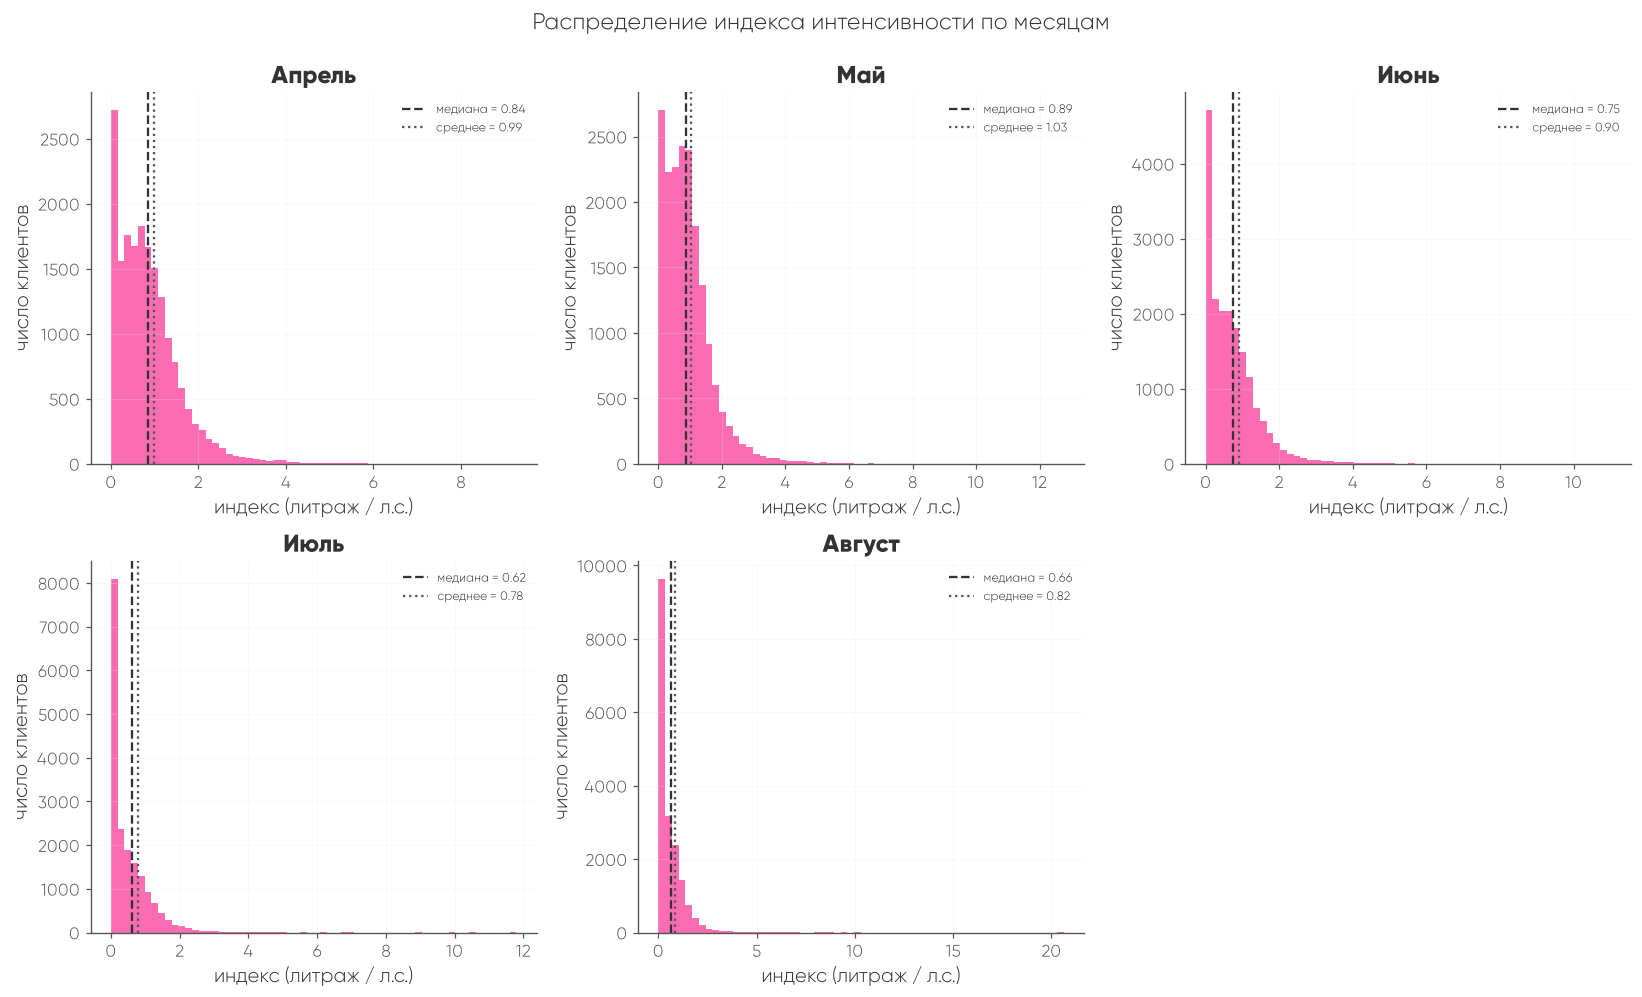

        index_m4   index_m5   index_m6   index_m7   index_m8
count  18285.000  18285.000  18285.000  18285.000  18285.000
mean       0.864      0.925      0.700      0.480      0.512
std        0.761      0.784      0.711      0.637      0.678
min        0.000      0.000      0.000      0.000      0.000
25%        0.334      0.386      0.169      0.000      0.000
50%        0.737      0.805      0.568      0.267      0.304
75%        1.198      1.258      1.028      0.754      0.806
max        9.266     12.754     11.015     11.791     20.623


In [7]:
# --- считаем литры по каждому месяцу отдельно (апрель-август), по клиенту
fuel_clean = fuel[(fuel.order_fuel_volume > 0) & (fuel.order_fuel_volume <= 100) &
                  (fuel.order_fuel_price_1liter.between(40, 150))].copy()
fuel_clean = fuel_clean[fuel_clean.order_datetime.between('2026-04-01', '2026-08-31')]
fuel_clean['month'] = fuel_clean.order_datetime.dt.month

L_by_month = fuel_clean.groupby(['client_id', 'month']).order_fuel_volume.sum().unstack(fill_value=0)
L_by_month.columns = [f'L_m{c}' for c in L_by_month.columns]

# --- индекс за каждый месяц = литры этого месяца / л.с. (engine_hp берём из d, уже отфильтрован)
idx_months = d[['client_id', 'engine_hp']].merge(L_by_month, on='client_id', how='left').fillna(0)

month_names = {4: 'Апрель', 5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август'}
for m in [4, 5, 6, 7, 8]:
    idx_months[f'index_m{m}'] = idx_months[f'L_m{m}'] / idx_months.engine_hp

# --- график: гистограмма индекса по каждому месяцу
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, m in enumerate([4, 5, 6, 7, 8]):
    ax = axes[i]
    data = idx_months[f'index_m{m}']
    data_nz = data[data > 0]   # для читаемости медианы/среднего считаем только среди заправлявшихся в этом месяце

    ax.hist(data, bins=60, color=PINK, alpha=.85)
    ax.axvline(data_nz.median(), color=INK, ls='--', lw=1.5, label=f'медиана = {data_nz.median():.2f}')
    ax.axvline(data_nz.mean(), color=MUTE, ls=':', lw=1.5, label=f'среднее = {data_nz.mean():.2f}')

    ax.set_xlabel('индекс (литраж / л.с.)')
    ax.set_ylabel('число клиентов')
    ax.set_title(month_names[m])
    ax.legend(frameon=False, fontsize=8)

axes[-1].axis('off')  # последняя (6-я) ячейка пустая, месяцев только 5

fig.suptitle('Распределение индекса интенсивности по месяцам', fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

print(idx_months[[f'index_m{m}' for m in [4,5,6,7,8]]].describe().round(3))

findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.


        index_m4   index_m5   index_m6   index_m7   index_m8
count  18285.000  18285.000  18285.000  18285.000  18285.000
mean       0.864      0.925      0.700      0.480      0.512
std        0.761      0.784      0.711      0.637      0.678
min        0.000      0.000      0.000      0.000      0.000
25%        0.334      0.386      0.169      0.000      0.000
50%        0.737      0.805      0.568      0.267      0.304
75%        1.198      1.258      1.028      0.754      0.806
max        9.266     12.754     11.015     11.791     20.623


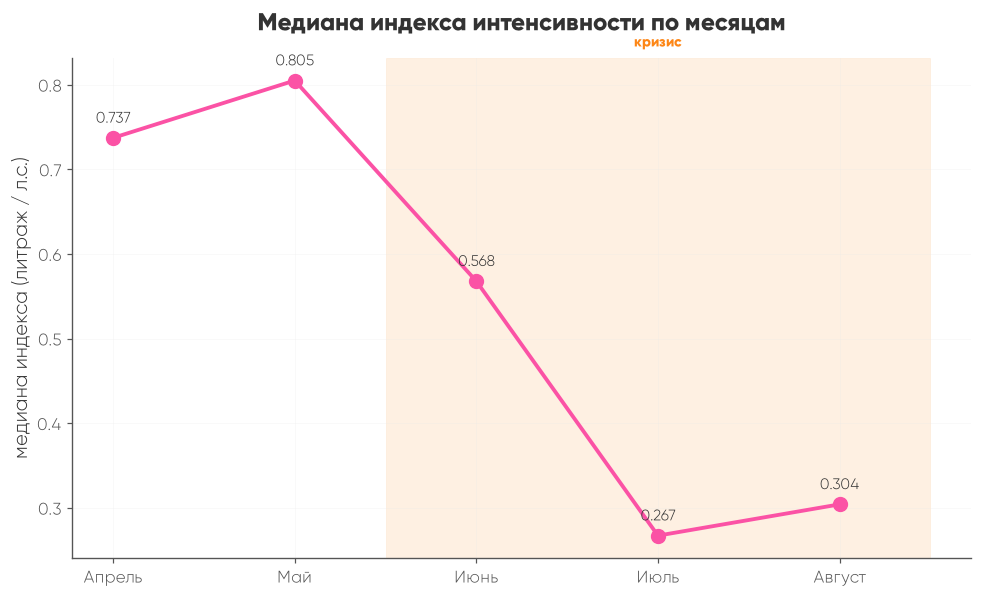

Апрель    0.737
Май       0.805
Июнь      0.568
Июль      0.267
Август    0.304
dtype: float64


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ================== ИНДЕКС ПОМЕСЯЧНО (литры каждого месяца / л.с.) ==================
fuel_clean = fuel[(fuel.order_fuel_volume > 0) & (fuel.order_fuel_volume <= 100) &
                  (fuel.order_fuel_price_1liter.between(40, 150))].copy()
fuel_clean = fuel_clean[fuel_clean.order_datetime.between('2026-04-01', '2026-08-31')]
fuel_clean['month'] = fuel_clean.order_datetime.dt.month

L_by_month = fuel_clean.groupby(['client_id', 'month']).order_fuel_volume.sum().unstack(fill_value=0)
L_by_month.columns = [f'L_m{c}' for c in L_by_month.columns]

idx_months = d[['client_id', 'engine_hp']].merge(L_by_month, on='client_id', how='left').fillna(0)

for m in [4, 5, 6, 7, 8]:
    idx_months[f'index_m{m}'] = idx_months[f'L_m{m}'] / idx_months.engine_hp

print(idx_months[[f'index_m{m}' for m in [4,5,6,7,8]]].describe().round(3))

# ================== МЕДИАНА ПО МЕСЯЦАМ ==================
month_names = ['Апрель', 'Май', 'Июнь', 'Июль', 'Август']
medians = [idx_months[f'index_m{m}'].median() for m in [4, 5, 6, 7, 8]]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(month_names, medians, marker='o', ms=9, lw=2.5, color=PINK)

for x, y in zip(month_names, medians):
    ax.annotate(f'{y:.3f}', (x, y), xytext=(0, 10), textcoords='offset points',
               ha='center', fontsize=10, color=INK)

ax.axvspan(1.5, 4.5, color=ORANGE, alpha=.12)
ax.text(3, max(medians)*1.05, 'кризис', ha='center', fontsize=9.5, color=ORANGE, fontweight='bold')

ax.set_ylabel('медиана индекса (литраж / л.с.)')
ax.set_title('Медиана индекса интенсивности по месяцам', pad=18)

plt.tight_layout()
plt.show()

print(pd.Series(medians, index=month_names).round(3))

findfont: Failed to find font weight regular for Gilroy, now using 300.


размеры категорий:
категория
Активные аккуратисты    7883
Редкие аккуратисты      6888
Редкие лихачи           2254
Активные лихачи         1260
Name: count, dtype: int64


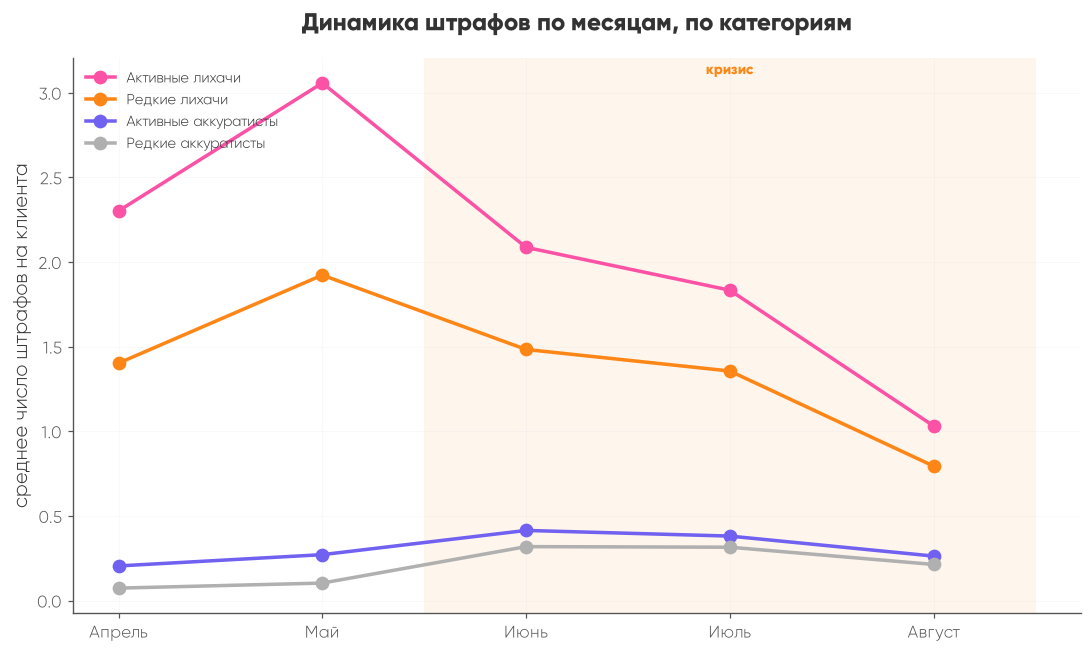

                      Апрель    Май   Июнь   Июль  Август
категория                                                
Активные лихачи        2.302  3.058  2.087  1.834   1.033
Редкие лихачи          1.403  1.923  1.484  1.357   0.795
Активные аккуратисты   0.205  0.272  0.415  0.382   0.264
Редкие аккуратисты     0.074  0.104  0.319  0.316   0.214


In [9]:
import pandas as pd
import numpy as np

# ================== ДЕРЕВО КАТЕГОРИЗАЦИИ ==================
med_idx = d['index'].median()
d['частота'] = np.where(d['index'] >= med_idx, 'часто', 'редко')

d['fine_rate_pre'] = d.fines_pre / d.L_month
med_rate = d[d.fine_rate_pre > 0].fine_rate_pre.median()
d['лихачество'] = np.where(d.fine_rate_pre >= med_rate, 'лихач', 'аккуратный')

def name_it(row):
    if row.частота == 'часто' and row.лихачество == 'лихач': return 'Активные лихачи'
    if row.частота == 'часто' and row.лихачество == 'аккуратный': return 'Активные аккуратисты'
    if row.частота == 'редко' and row.лихачество == 'лихач': return 'Редкие лихачи'
    return 'Редкие аккуратисты'

d['категория'] = d.apply(name_it, axis=1)

print('размеры категорий:')
print(d.категория.value_counts())

# ================== ШТРАФЫ ПО МЕСЯЦАМ, ПО КАТЕГОРИИ ==================
fines_m = fines[fines.bill_offence_date.between('2026-04-01', '2026-08-31')].copy()
fines_m['month'] = fines_m.bill_offence_date.dt.month

fines_by_month = fines_m.groupby(['client_id', 'month']).size().unstack(fill_value=0)
fine_cols = []
for m in [4, 5, 6, 7, 8]:
    if m not in fines_by_month.columns:
        fines_by_month[m] = 0
    fine_cols.append(m)
fines_by_month = fines_by_month[fine_cols]
fines_by_month.columns = [f'fines_m{m}' for m in fine_cols]

d_months = d[['client_id', 'категория']].merge(fines_by_month, on='client_id', how='left')
d_months[[f'fines_m{m}' for m in fine_cols]] = d_months[[f'fines_m{m}' for m in fine_cols]].fillna(0)

month_names = ['Апрель', 'Май', 'Июнь', 'Июль', 'Август']
monthly = d_months.groupby('категория')[[f'fines_m{m}' for m in fine_cols]].mean()
monthly.columns = month_names

order = ['Активные лихачи', 'Редкие лихачи', 'Активные аккуратисты', 'Редкие аккуратисты']
monthly = monthly.reindex(order)

# ================== ЛИНЕЙНЫЙ ГРАФИК ==================
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Активные лихачи': PINK, 'Редкие лихачи': ORANGE,
         'Активные аккуратисты': PURPLE, 'Редкие аккуратисты': GREY}

for cat in order:
    ax.plot(month_names, monthly.loc[cat], marker='o', ms=8, lw=2.3,
           color=colors[cat], label=cat)

ax.axvspan(1.5, 4.5, color=ORANGE, alpha=.08)
ax.text(3, ax.get_ylim()[1]*0.97, 'кризис', ha='center', fontsize=9.5, color=ORANGE, fontweight='bold')

ax.set_ylabel('среднее число штрафов на клиента')
ax.set_title('Динамика штрафов по месяцам, по категориям', pad=18)
ax.legend(frameon=False, loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.show()

print(monthly.round(3))

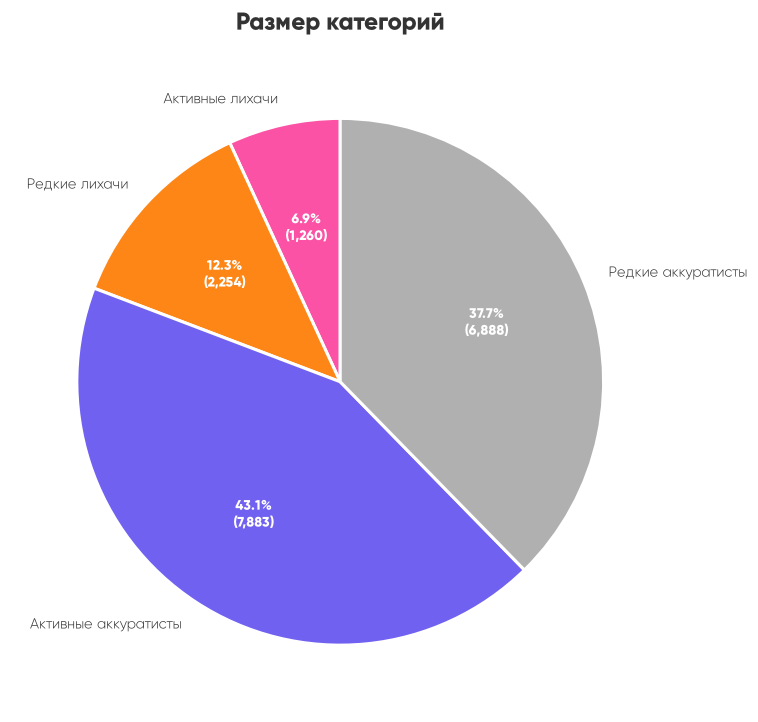

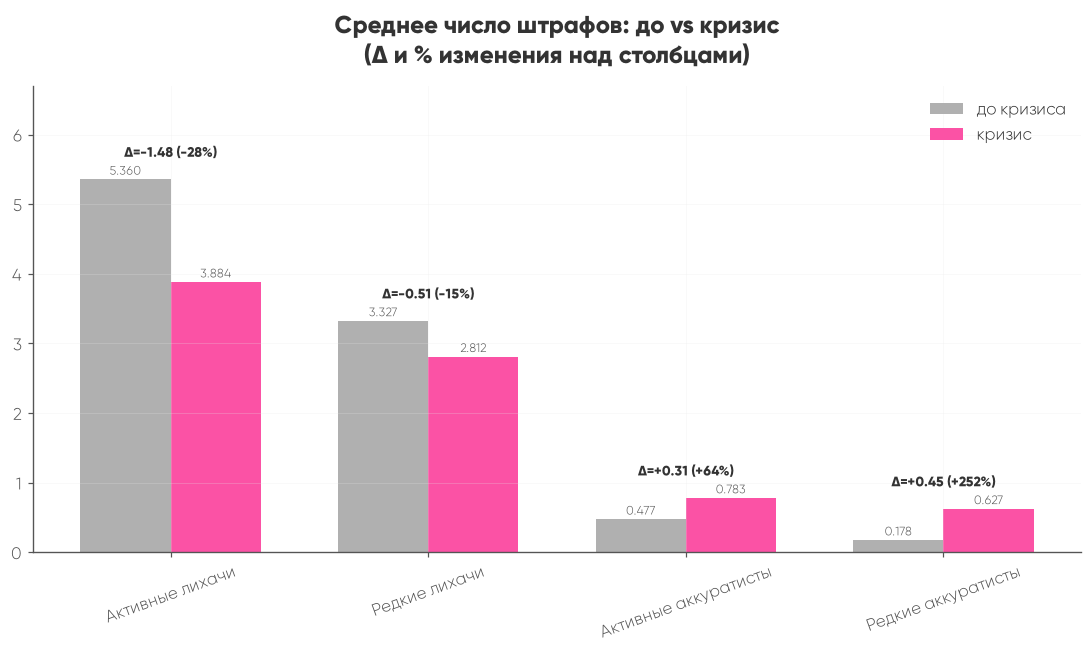

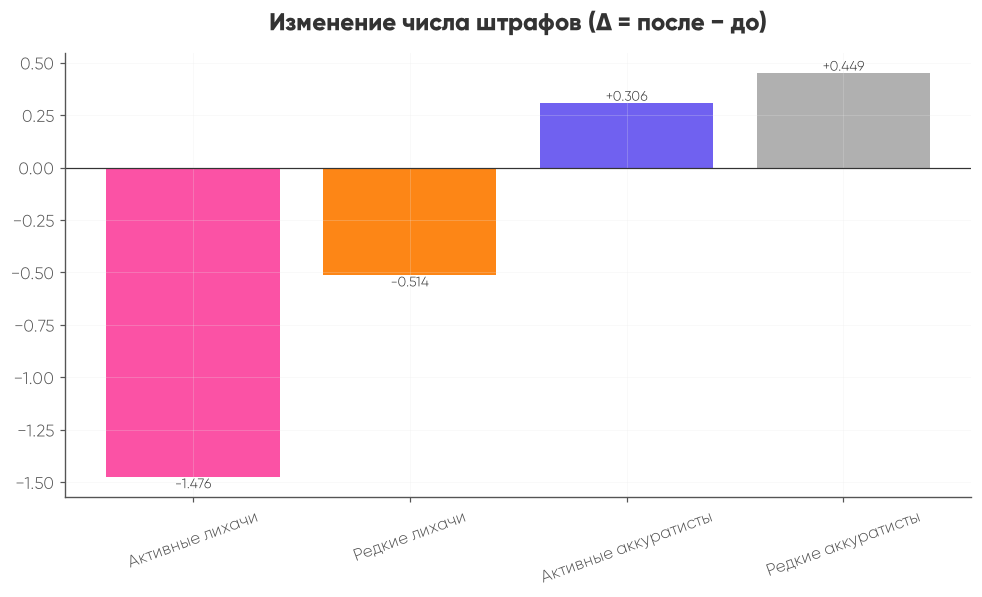

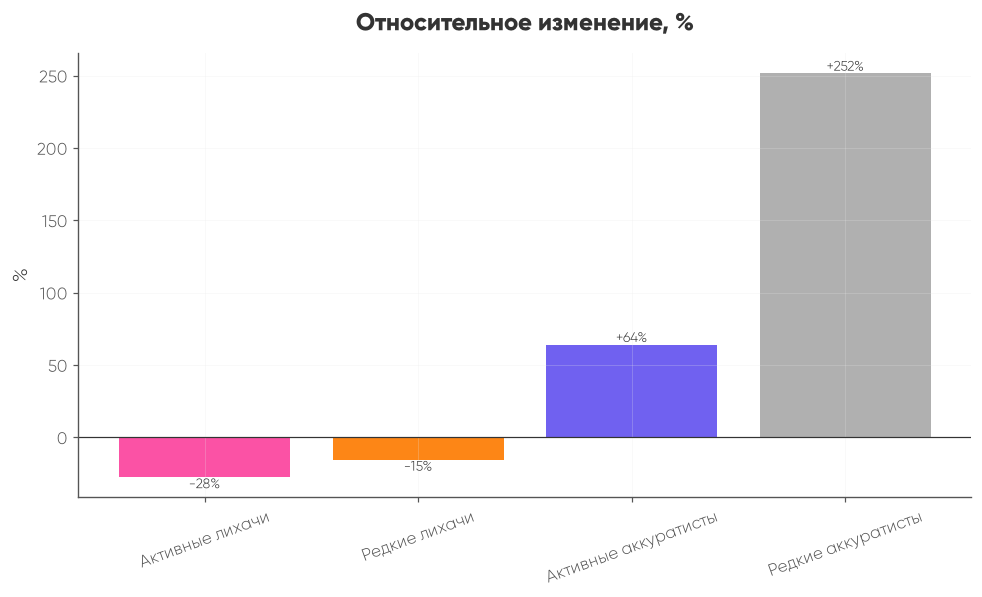

                      fines_pre  fines_post   delta
категория                                          
Активные лихачи          5.3603      3.8841 -1.4762
Редкие лихачи            3.3265      2.8123 -0.5142
Активные аккуратисты     0.4774      0.7831  0.3057
Редкие аккуратисты       0.1784      0.6273  0.4489


In [24]:
import pandas as pd
import numpy as np

# ================== ДЕРЕВО КАТЕГОРИЗАЦИИ ==================
med_idx = d['index'].median()
d['частота'] = np.where(d['index'] >= med_idx, 'часто', 'редко')

d['fine_rate_pre'] = d.fines_pre / d.L_month
med_rate = d[d.fine_rate_pre > 0].fine_rate_pre.median()
d['лихачество'] = np.where(d.fine_rate_pre >= med_rate, 'лихач', 'аккуратный')

def name_it(row):
    if row.частота == 'часто' and row.лихачество == 'лихач': return 'Активные лихачи'
    if row.частота == 'часто' and row.лихачество == 'аккуратный': return 'Активные аккуратисты'
    if row.частота == 'редко' and row.лихачество == 'лихач': return 'Редкие лихачи'
    return 'Редкие аккуратисты'

d['категория'] = d.apply(name_it, axis=1)

order = ['Активные лихачи', 'Редкие лихачи', 'Активные аккуратисты', 'Редкие аккуратисты']
colors = {'Активные лихачи': PINK, 'Редкие лихачи': ORANGE,
         'Активные аккуратисты': PURPLE, 'Редкие аккуратисты': GREY}

summary = d.groupby('категория')[['fines_pre', 'fines_post', 'delta']].mean().reindex(order)
sizes = d.категория.value_counts().reindex(order)

# ================== ГРАФИК 1: пайчарт — доли категорий ==================
fig1, ax1 = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax1.pie(
    sizes.values, labels=order,
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*sizes.sum()):,})',
    colors=[colors[c] for c in order], startangle=90,
    wedgeprops={'edgecolor': WHITE, 'linewidth': 2}, textprops={'fontsize': 9.5})
for at in autotexts:
    at.set_color(WHITE); at.set_fontweight('bold'); at.set_fontsize(9)
ax1.set_title('Размер категорий', pad=15)
plt.tight_layout()
plt.show()

# ================== ГРАФИК 2: штрафы до/после + дельта и % изменения ==================
fig2, ax2 = plt.subplots(figsize=(10, 6))
x = np.arange(len(order)); w = .35
bars_pre = ax2.bar(x - w/2, summary.fines_pre, w, label='до кризиса', color=GREY)
bars_post = ax2.bar(x + w/2, summary.fines_post, w, label='кризис', color=PINK)
ax2.set_xticks(x); ax2.set_xticklabels(order, rotation=20)
ax2.set_title('Среднее число штрафов: до vs кризис\n(Δ и % изменения над столбцами)', pad=15)
ax2.legend(frameon=False)

# подписи значений на каждом столбце
for b in bars_pre:
    ax2.annotate(f'{b.get_height():.3f}', (b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=MUTE)
for b in bars_post:
    ax2.annotate(f'{b.get_height():.3f}', (b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=MUTE)

# дельта и % изменения над парой столбцов
rel = (summary.fines_post / summary.fines_pre - 1) * 100
ymax = max(summary.fines_pre.max(), summary.fines_post.max())
for i, cat in enumerate(order):
    delta_v = summary.delta.loc[cat]
    rel_v = rel.loc[cat]
    top_y = max(summary.fines_pre.loc[cat], summary.fines_post.loc[cat])
    ax2.annotate(f'Δ={delta_v:+.2f} ({rel_v:+.0f}%)', (i, top_y + ymax * 0.06),
                ha='center', fontsize=9, fontweight='bold',
                color=INK)

ax2.set_ylim(0, ymax * 1.25)
plt.tight_layout()
plt.show()

# ================== ГРАФИК 3: изменение (delta) ==================
fig3, ax3 = plt.subplots(figsize=(9, 5.5))
ax3.bar(order, summary.delta, color=[colors[c] for c in order])
ax3.axhline(0, color=INK, lw=.8)
ax3.set_title('Изменение числа штрафов (Δ = после − до)', pad=15)
ax3.tick_params(axis='x', rotation=20)
for i, v in enumerate(summary.delta):
    ax3.annotate(f'{v:+.3f}', (i, v), ha='center', va='bottom' if v > 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()

# ================== ГРАФИК 4: относительное изменение, % ==================
fig4, ax4 = plt.subplots(figsize=(9, 5.5))
rel = (summary.fines_post / summary.fines_pre - 1) * 100
ax4.bar(order, rel, color=[colors[c] for c in order])
ax4.axhline(0, color=INK, lw=.8)
ax4.set_title('Относительное изменение, %', pad=15)
ax4.set_ylabel('%')
ax4.tick_params(axis='x', rotation=20)
for i, v in enumerate(rel):
    ax4.annotate(f'{v:+.0f}%', (i, v), ha='center', va='bottom' if v > 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()

print(summary.round(4))

колонки panel: ['client_id', 'month', 'liters', 'fines', 'категория', 'log_liters', 'region_group_x', 'region_group_y']
panel_pre колонки: ['client_id', 'fines_pre_p', 'liters_pre_p']
panel_post колонки: ['client_id', 'fines_post_p', 'liters_post_p']
колонки d после мерджа: ['liters_pre_p_x', 'liters_post_p_x', 'liters_pre_p_y', 'liters_post_p_y', 'fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p']
                      rate_pre  rate_post  rate_delta
категория                                            
Активные лихачи        0.01564    0.02374     0.00810
Редкие лихачи          0.02305    0.01853    -0.00452
Активные аккуратисты   0.00124    0.00446     0.00322
Редкие аккуратисты     0.00080    0.00420     0.00340


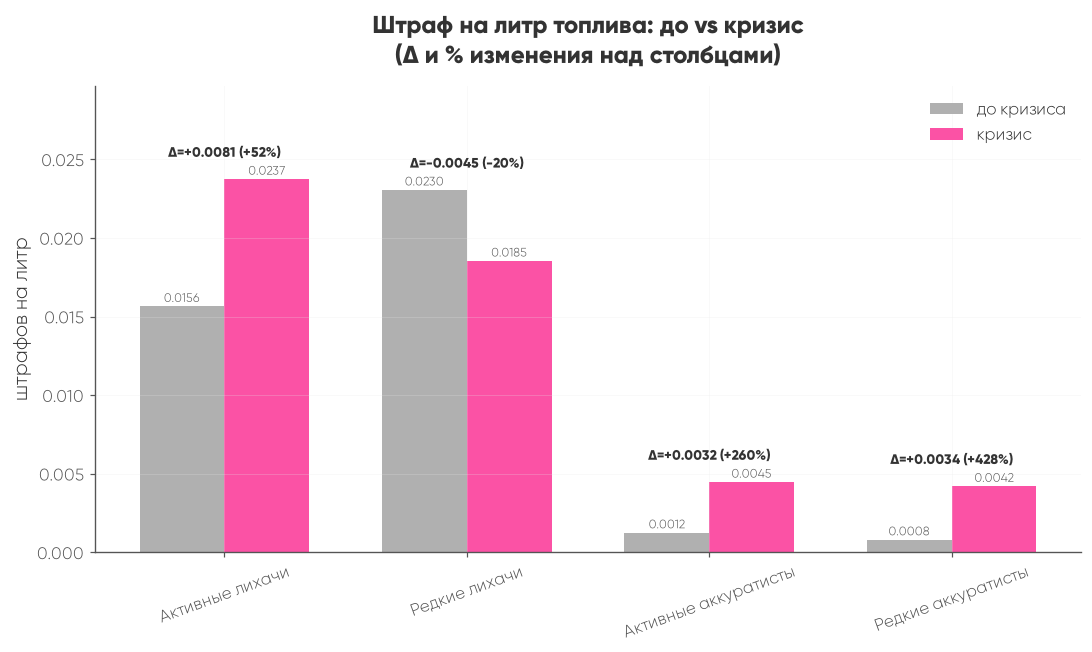

In [28]:
import pandas as pd
import numpy as np

# ================== ИНТЕНСИВНОСТЬ: штраф НА ЛИТР, на основе panel ==================

# --- проверка исходных данных
print('колонки panel:', panel.columns.tolist())
assert {'client_id', 'month', 'fines', 'liters'}.issubset(panel.columns), 'в panel нет нужных колонок'

# --- считаем сумму штрафов и литров отдельно за "до" и "после", с явным reset_index
panel_pre = (panel[panel.month.isin([4, 5])]
            .groupby('client_id', as_index=False)
            .agg(fines_pre_p=('fines', 'sum'), liters_pre_p=('liters', 'sum')))

panel_post = (panel[panel.month.isin([6, 7])]
             .groupby('client_id', as_index=False)
             .agg(fines_post_p=('fines', 'sum'), liters_post_p=('liters', 'sum')))

print('panel_pre колонки:', panel_pre.columns.tolist())
print('panel_post колонки:', panel_post.columns.tolist())

# --- удаляем возможные старые версии этих колонок в d (если код запускался раньше)
cols_to_add = ['fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p', 'rate_pre', 'rate_post']
d = d.drop(columns=[c for c in cols_to_add if c in d.columns])

# --- мерджим
d = d.merge(panel_pre, on='client_id', how='left')
d = d.merge(panel_post, on='client_id', how='left')

print('колонки d после мерджа:', [c for c in d.columns if 'p_' in c or c in cols_to_add])
assert 'liters_pre_p' in d.columns, 'liters_pre_p всё ещё не появился — проверь panel_pre выше'

d[['fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p']] = d[
    ['fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p']].fillna(0)

d['rate_pre'] = d.fines_pre_p / d.liters_pre_p.replace(0, np.nan)
d['rate_post'] = d.fines_post_p / d.liters_post_p.replace(0, np.nan)

summary_rate = d.groupby('категория')[['rate_pre', 'rate_post']].mean().reindex(order)
summary_rate['rate_delta'] = summary_rate.rate_post - summary_rate.rate_pre

print(summary_rate.round(5))

# ================== ГРАФИК: штраф на литр, до/после + дельта и % изменения ==================
fig5, ax5 = plt.subplots(figsize=(10, 6))
x = np.arange(len(order)); w = .35
bars_pre = ax5.bar(x - w/2, summary_rate.rate_pre, w, label='до кризиса', color=GREY)
bars_post = ax5.bar(x + w/2, summary_rate.rate_post, w, label='кризис', color=PINK)
ax5.set_xticks(x); ax5.set_xticklabels(order, rotation=20)
ax5.set_title('Штраф на литр топлива: до vs кризис\n(Δ и % изменения над столбцами)', pad=15)
ax5.set_ylabel('штрафов на литр')
ax5.legend(frameon=False)

for b in bars_pre:
    ax5.annotate(f'{b.get_height():.4f}', (b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=MUTE)
for b in bars_post:
    ax5.annotate(f'{b.get_height():.4f}', (b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=MUTE)

rel_rate = (summary_rate.rate_post / summary_rate.rate_pre - 1) * 100
ymax = max(summary_rate.rate_pre.max(), summary_rate.rate_post.max())
for i, cat in enumerate(order):
    delta_v = summary_rate.rate_delta.loc[cat]
    rel_v = rel_rate.loc[cat]
    top_y = max(summary_rate.rate_pre.loc[cat], summary_rate.rate_post.loc[cat])
    ax5.annotate(f'Δ={delta_v:+.4f} ({rel_v:+.0f}%)', (i, top_y + ymax * 0.06),
                ha='center', fontsize=9, fontweight='bold', color=INK)

ax5.set_ylim(0, ymax * 1.25)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight regular for Gilroy, now using 300.


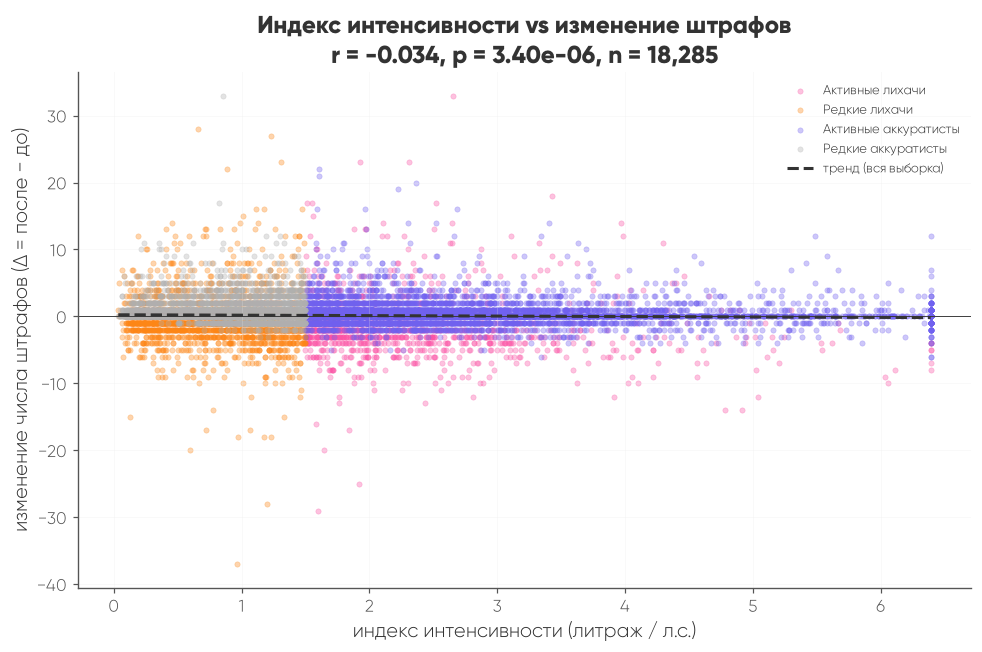

=== Корреляция index vs delta, по категориям ===
  Активные лихачи       : n= 1260  Пирсон r=-0.099 (p=0.000)  Спирмен ρ=-0.127 (p=0.000)
  Редкие лихачи         : n= 2254  Пирсон r=-0.070 (p=0.001)  Спирмен ρ=-0.140 (p=0.000)
  Активные аккуратисты  : n= 7883  Пирсон r=-0.026 (p=0.021)  Спирмен ρ=-0.019 (p=0.091)
  Редкие аккуратисты    : n= 6888  Пирсон r=-0.028 (p=0.022)  Спирмен ρ=-0.059 (p=0.000)


KeyError: 'Пирсон r'

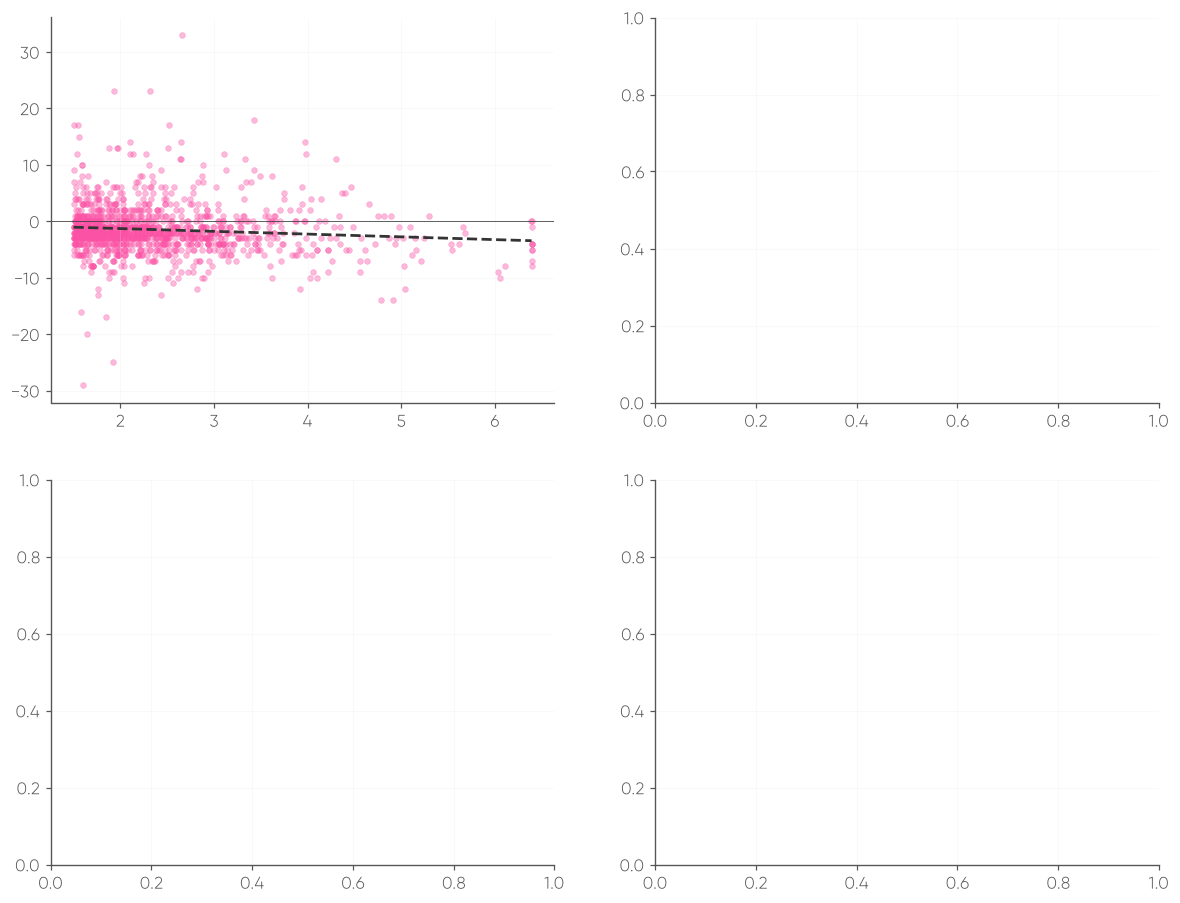

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ================== 1. Scatter: index vs delta, по всей таблице ==================
fig, ax = plt.subplots(figsize=(9, 6))

colors_cat = {'Активные лихачи': PINK, 'Редкие лихачи': ORANGE,
             'Активные аккуратисты': PURPLE, 'Редкие аккуратисты': GREY}

for cat, color in colors_cat.items():
    sub = d[d.категория == cat]
    ax.scatter(sub['index'], sub.delta, s=12, alpha=.35, color=color, label=cat)

# линия тренда по ВСЕЙ выборке
z = np.polyfit(d['index'], d.delta, 1)
xs = np.linspace(d['index'].min(), d['index'].max(), 50)
ax.plot(xs, np.polyval(z, xs), '--', color=INK, lw=2, label='тренд (вся выборка)')

r, p = stats.pearsonr(d['index'], d.delta)
ax.axhline(0, color=INK, lw=.6)
ax.set_xlabel('индекс интенсивности (литраж / л.с.)')
ax.set_ylabel('изменение числа штрафов (Δ = после − до)')
ax.set_title(f'Индекс интенсивности vs изменение штрафов\nr = {r:+.3f}, p = {p:.2e}, n = {len(d):,}')
ax.legend(frameon=False, fontsize=8.5, loc='upper right')

plt.tight_layout()
plt.show()

# ================== 2. Корреляция ОТДЕЛЬНО по каждой из 4 категорий ==================
print('=== Корреляция index vs delta, по категориям ===')
order = ['Активные лихачи', 'Редкие лихачи', 'Активные аккуратисты', 'Редкие аккуратисты']
corr_by_cat = []
for cat in order:
    sub = d[d.категория == cat]
    r_c, p_c = stats.pearsonr(sub['index'], sub.delta)
    rs_c, ps_c = stats.spearmanr(sub['index'], sub.delta)
    corr_by_cat.append({'категория': cat, 'n': len(sub), 'каж': r_c, 'p (Пирсон)': p_c,
                        'Спирмен ρ': rs_c, 'p (Спирмен)': ps_c})
    print(f'  {cat:22s}: n={len(sub):5d}  Пирсон r={r_c:+.3f} (p={p_c:.3f})  Спирмен ρ={rs_c:+.3f} (p={ps_c:.3f})')

corr_df = pd.DataFrame(corr_by_cat).set_index('категория')

# ================== 3. Визуализация корреляций по категориям (4 отдельные панели) ==================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, cat in zip(axes, order):
    sub = d[d.категория == cat]
    ax.scatter(sub['index'], sub.delta, s=14, alpha=.4, color=colors_cat[cat])
    if len(sub) > 2:
        z = np.polyfit(sub['index'], sub.delta, 1)
        xs = np.linspace(sub['index'].min(), sub['index'].max(), 30)
        ax.plot(xs, np.polyval(z, xs), '--', color=INK, lw=1.8)
    ax.axhline(0, color=INK, lw=.5)
    r_c = corr_df.loc[cat, 'Пирсон r']; p_c = corr_df.loc[cat, 'p (Пирсон)']
    ax.set_title(f'{cat}\nr={r_c:+.3f}, p={p_c:.3f}, n={corr_df.loc[cat,"n"]}', fontsize=11)
    ax.set_xlabel('индекс интенсивности'); ax.set_ylabel('Δ штрафов')

plt.tight_layout()
plt.show()

print('\n=== Сводная таблица ===')
print(corr_df.round(4))

In [23]:
import pandas as pd
from scipy.stats import chi2_contingency

# ================== ТАБЛИЦА СОПРЯЖЁННОСТИ ==================
ct = pd.DataFrame({
    'Активные': [1260, 7883],
    'Редкие':   [2254, 6888],
}, index=['Лихачи', 'Аккуратисты'])

print(ct)

# ================== ХИ-КВАДРАТ ТЕСТ ==================
chi2, p, dof, expected = chi2_contingency(ct)

print(f'\nchi2 = {chi2:.2f}')
print(f'df = {dof}')
print(f'p-value = {p:.2e}')

if p < 0.05:
    print('\np < 0.05 → отвергаем независимость: связь есть.')
else:
    print('\np >= 0.05 → независимость не отвергается.')

             Активные  Редкие
Лихачи           1260    2254
Аккуратисты      7883    6888

chi2 = 347.50
df = 1
p-value = 1.49e-77

p < 0.05 → отвергаем независимость: связь есть.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем метрику интенсивности: штрафы на 1000 литров топлива
panel['fines_per_1k_liters'] = (panel['fines'] / panel['liters']) * 1000

# 2. Строим график временных профилей
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=panel, 
    x='month', 
    y='fines_per_1k_liters', 
    hue='категория', 
    marker='o', 
    errorbar=('ci', 95), # Добавляет доверительные интервалы 95%
    linewidth=2.5
)

plt.title('Динамика интенсивности штрафов по категориям (на 1000 л)')
plt.xlabel('Месяц (2026 год)')
plt.ylabel('Среднее число штрафов на 1000 литров')
plt.xticks([4, 5, 6, 7], ['Апрель', 'Май', 'Июнь', 'Июль'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Категория')
plt.show()


findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.


                      rate_pre  rate_post  rate_delta
категория                                            
Активные лихачи        0.01564    0.02374     0.00810
Редкие лихачи          0.02305    0.01853    -0.00452
Активные аккуратисты   0.00124    0.00446     0.00322
Редкие аккуратисты     0.00080    0.00420     0.00340


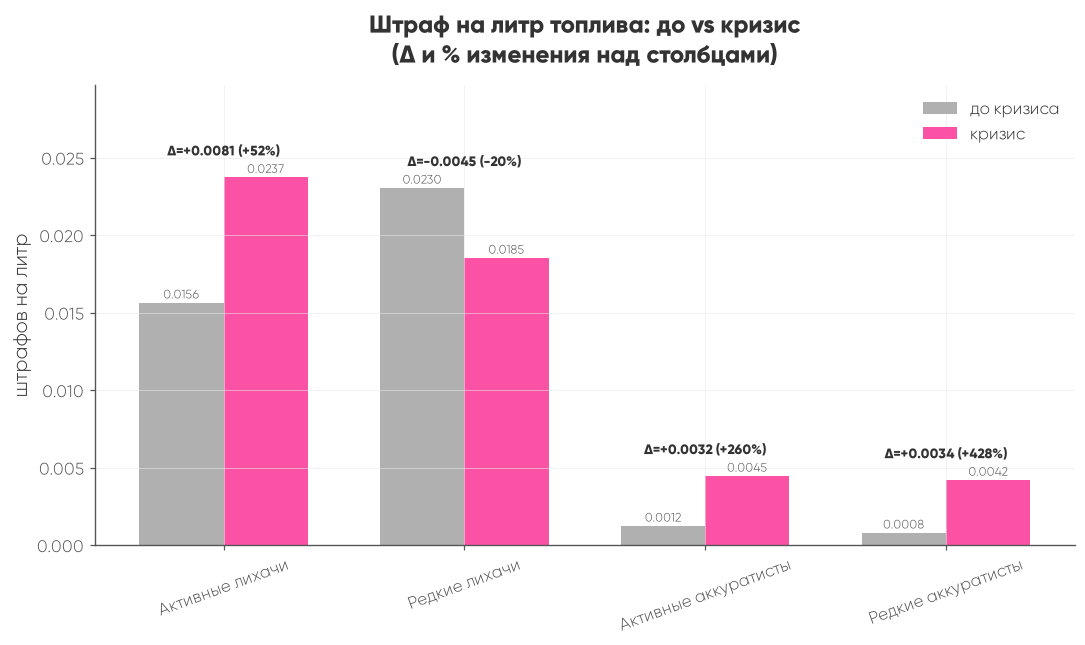

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

order = ['Активные лихачи', 'Редкие лихачи', 'Активные аккуратисты', 'Редкие аккуратисты']
colors = {'Активные лихачи': PINK, 'Редкие лихачи': ORANGE,
         'Активные аккуратисты': PURPLE, 'Редкие аккуратисты': GREY}

# ================== ИНТЕНСИВНОСТЬ: штраф НА ЛИТР, на основе panel ==================
panel_pre = (panel[panel.month.isin([4, 5])]
            .groupby('client_id', as_index=False)
            .agg(fines_pre_p=('fines', 'sum'), liters_pre_p=('liters', 'sum')))

panel_post = (panel[panel.month.isin([6, 7])]
             .groupby('client_id', as_index=False)
             .agg(fines_post_p=('fines', 'sum'), liters_post_p=('liters', 'sum')))

cols_to_add = ['fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p', 'rate_pre', 'rate_post']
d = d.drop(columns=[c for c in cols_to_add if c in d.columns])
d = d.merge(panel_pre, on='client_id', how='left')
d = d.merge(panel_post, on='client_id', how='left')
d[['fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p']] = d[
    ['fines_pre_p', 'liters_pre_p', 'fines_post_p', 'liters_post_p']].fillna(0)

d['rate_pre'] = d.fines_pre_p / d.liters_pre_p.replace(0, np.nan)
d['rate_post'] = d.fines_post_p / d.liters_post_p.replace(0, np.nan)

summary_rate = d.groupby('категория')[['rate_pre', 'rate_post']].mean().reindex(order)
summary_rate['rate_delta'] = summary_rate.rate_post - summary_rate.rate_pre

print(summary_rate.round(5))

# ================== ГРАФИК: штраф на литр, до/после + Δ и % изменения ==================
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(order)); w = .35
bars_pre = ax.bar(x - w/2, summary_rate.rate_pre, w, label='до кризиса', color=GREY)
bars_post = ax.bar(x + w/2, summary_rate.rate_post, w, label='кризис', color=PINK)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20)
ax.set_title('Штраф на литр топлива: до vs кризис\n(Δ и % изменения над столбцами)', pad=15)
ax.set_ylabel('штрафов на литр')
ax.legend(frameon=False)

for b in bars_pre:
    ax.annotate(f'{b.get_height():.4f}', (b.get_x() + b.get_width()/2, b.get_height()),
               xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=MUTE)
for b in bars_post:
    ax.annotate(f'{b.get_height():.4f}', (b.get_x() + b.get_width()/2, b.get_height()),
               xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=MUTE)

rel_rate = (summary_rate.rate_post / summary_rate.rate_pre - 1) * 100
ymax = max(summary_rate.rate_pre.max(), summary_rate.rate_post.max())
for i, cat in enumerate(order):
    delta_v = summary_rate.rate_delta.loc[cat]
    rel_v = rel_rate.loc[cat]
    top_y = max(summary_rate.rate_pre.loc[cat], summary_rate.rate_post.loc[cat])
    ax.annotate(f'Δ={delta_v:+.4f} ({rel_v:+.0f}%)', (i, top_y + ymax * 0.06),
               ha='center', fontsize=9, fontweight='bold', color=INK)

ax.set_ylim(0, ymax * 1.25)
plt.tight_layout()
plt.savefig('rate_before_after.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson

# ================== ПАНЕЛЬ: клиент x месяц (апрель-июль) ==================
fuel_c = fuel[(fuel.order_fuel_volume > 0) & (fuel.order_fuel_volume <= 100) &
             (fuel.order_fuel_price_1liter.between(40, 150))]
fuel_c = fuel_c[fuel_c.order_datetime.between('2026-04-01', '2026-07-31')].copy()
fuel_c['month'] = fuel_c.order_datetime.dt.month
liters_cm = fuel_c.groupby(['client_id', 'month']).order_fuel_volume.sum().rename('liters').reset_index()

fines_w = fines[fines.bill_offence_date.between('2026-04-01', '2026-07-31')].copy()
fines_w['month'] = fines_w.bill_offence_date.dt.month
fines_cm = fines_w.groupby(['client_id', 'month']).size().rename('fines').reset_index()

ids = d.client_id.unique()
grid = pd.MultiIndex.from_product([ids, [4, 5, 6, 7]], names=['client_id', 'month']).to_frame(index=False)
panel = (grid.merge(liters_cm, on=['client_id', 'month'], how='left')
             .merge(fines_cm, on=['client_id', 'month'], how='left'))
panel[['liters', 'fines']] = panel[['liters', 'fines']].fillna(0)
panel = panel.merge(d[['client_id', 'категория']], on='client_id', how='left')
panel = panel[panel.liters > 0].copy()
panel['log_liters'] = np.log(panel.liters)
panel = panel.sort_values(['client_id', 'month']).reset_index(drop=True)

# ================== ТЕСТ: GEE, Poisson, offset=log(литры), группировка по client_id ==================
model = smf.gee('fines ~ C(категория) * C(month)', groups='client_id', data=panel,
                family=Poisson(), cov_struct=Exchangeable(), offset=panel.log_liters)
res = model.fit()
print(res.summary())

                               GEE Regression Results                              
Dep. Variable:                       fines   No. Observations:                57772
Model:                                 GEE   No. clusters:                    18285
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   4
Family:                            Poisson   Mean cluster size:                 3.2
Dependence structure:         Exchangeable   Num. iterations:                    10
Date:                     Sun, 20 Sep 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         09:12:29
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept 

               категория  месяц   coef     lo     hi      p
0        Активные лихачи      5  0.268  0.187  0.350  0.000
1        Активные лихачи      6  0.210  0.110  0.309  0.000
2        Активные лихачи      7  0.332  0.213  0.451  0.000
3   Активные аккуратисты      5  0.255  0.175  0.336  0.000
4   Активные аккуратисты      6  1.041  0.959  1.122  0.000
5   Активные аккуратисты      7  1.253  1.161  1.345  0.000
6          Редкие лихачи      5  0.261  0.159  0.364  0.000
7          Редкие лихачи      6 -0.220 -0.343 -0.097  0.000
8          Редкие лихачи      7 -0.272 -0.391 -0.152  0.000
9     Редкие аккуратисты      5  0.223  0.080  0.366  0.002
10    Редкие аккуратисты      6  1.304  1.179  1.429  0.000
11    Редкие аккуратисты      7  1.394  1.266  1.522  0.000


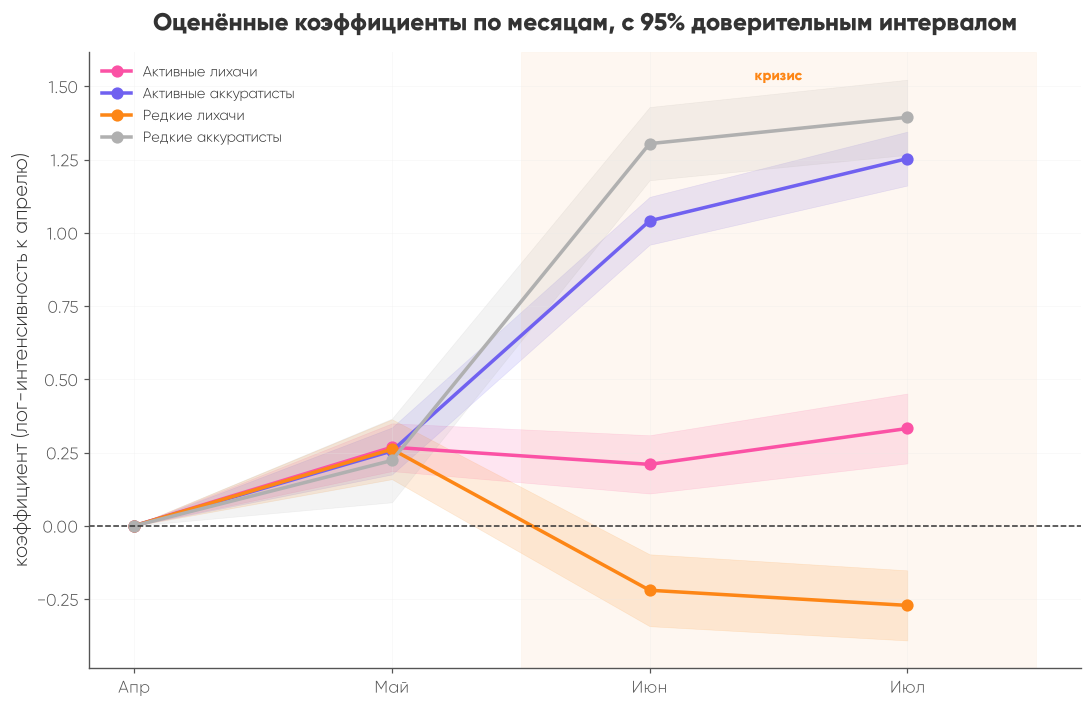

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

# ================== СЧИТАЕМ КОЭФФИЦИЕНТЫ С ДИ ДЛЯ КАЖДОЙ ИЗ 4 КАТЕГОРИЙ ОТДЕЛЬНО (без августа) ==================
order = ['Активные лихачи', 'Активные аккуратисты', 'Редкие лихачи', 'Редкие аккуратисты']
rows = []
for cat in order:
    sub = panel[(panel.категория == cat) & (panel.month <= 7)]   # убрали август

    m = smf.gee('fines ~ C(month)', groups='client_id', data=sub,
               family=Poisson(), cov_struct=Exchangeable(), offset=sub.log_liters)
    r = m.fit()
    t = r.summary2().tables[1]

    for mth in [5, 6, 7]:
        key = f'C(month)[T.{mth}]'
        if key in t.index:
            rows.append({'категория': cat, 'месяц': mth, 'coef': t.loc[key, 'Coef.'],
                        'lo': t.loc[key, '[0.025'], 'hi': t.loc[key, '0.975]'], 'p': t.loc[key, 'P>|z|']})

res_ci = pd.DataFrame(rows)
print(res_ci.round(3))

# ================== ГРАФИК: коэффициенты по месяцам, с 95% ДИ ==================
colors = {'Активные лихачи': PINK, 'Активные аккуратисты': PURPLE, 'Редкие лихачи': ORANGE, 'Редкие аккуратисты': GREY}
month_names = {4: 'Апр', 5: 'Май', 6: 'Июн', 7: 'Июл'}

fig, ax = plt.subplots(figsize=(10, 6.5))

for cat in order:
    sub = res_ci[res_ci.категория == cat].sort_values('месяц')
    if sub.empty:
        continue
    x = [4] + sub.месяц.tolist()
    y = [0] + sub.coef.tolist()
    lo = [0] + sub.lo.tolist()
    hi = [0] + sub.hi.tolist()
    xt = [month_names[m] for m in x]
    ax.plot(xt, y, marker='o', ms=7, lw=2.3, color=colors[cat], label=cat)
    ax.fill_between(xt, lo, hi, color=colors[cat], alpha=.15)

ax.axhline(0, color=INK, lw=1, ls='--')
ax.axvspan(1.5, 3.5, color=ORANGE, alpha=.06)
ax.text(2.5, ax.get_ylim()[1] * 0.94, 'кризис', ha='center', fontsize=9.5, color=ORANGE, fontweight='bold')

ax.set_ylabel('коэффициент (лог-интенсивность к апрелю)')
ax.set_title('Оценённые коэффициенты по месяцам, с 95% доверительным интервалом',
             pad=14, fontweight='bold')
ax.legend(frameon=False, loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.savefig('coef_ci_plot.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

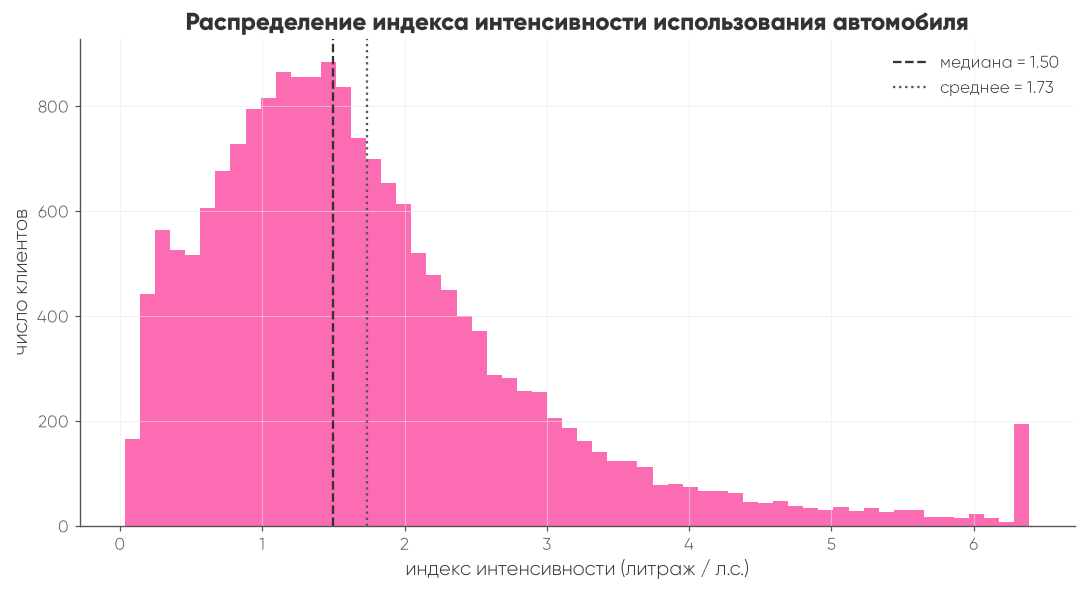

count    18285.000
mean         1.733
std          1.173
min          0.035
1%           0.146
10%          0.486
25%          0.929
50%          1.499
75%          2.236
90%          3.186
99%          6.391
max          6.392
Name: index, dtype: float64


In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(d['index'], bins=60, color=PINK, alpha=.85)

ax.axvline(d['index'].median(), color=INK, ls='--', lw=1.5, label=f'медиана = {d["index"].median():.2f}')
ax.axvline(d['index'].mean(), color=MUTE, ls=':', lw=1.5, label=f'среднее = {d["index"].mean():.2f}')

ax.set_xlabel('индекс интенсивности (литраж / л.с.)')
ax.set_ylabel('число клиентов')
ax.set_title('Распределение индекса интенсивности использования автомобиля')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('index_distribution.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

print(d['index'].describe(percentiles=[.01, .1, .25, .5, .75, .9, .99]).round(3))

findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.


    регион_группа            категория  месяц    n   coef     lo     hi     p   sig
           Москва      Активные лихачи      5  301  0.212  0.032  0.392 0.021  True
           Москва      Активные лихачи      6  301  0.531  0.329  0.734 0.000  True
           Москва      Активные лихачи      7  301  0.573  0.357  0.790 0.000  True
           Москва Активные аккуратисты      5 1418  0.286  0.111  0.461 0.001  True
           Москва Активные аккуратисты      6 1418  1.426  1.244  1.609 0.000  True
           Москва Активные аккуратисты      7 1418  1.595  1.401  1.789 0.000  True
           Москва        Редкие лихачи      5  502  0.193 -0.002  0.388 0.052 False
           Москва        Редкие лихачи      6  502  0.133 -0.093  0.359 0.249 False
           Москва        Редкие лихачи      7  502  0.001 -0.218  0.220 0.990 False
           Москва   Редкие аккуратисты      5 1528  0.172 -0.095  0.439 0.207 False
           Москва   Редкие аккуратисты      6 1528  1.479  1.244  1.714 0.00

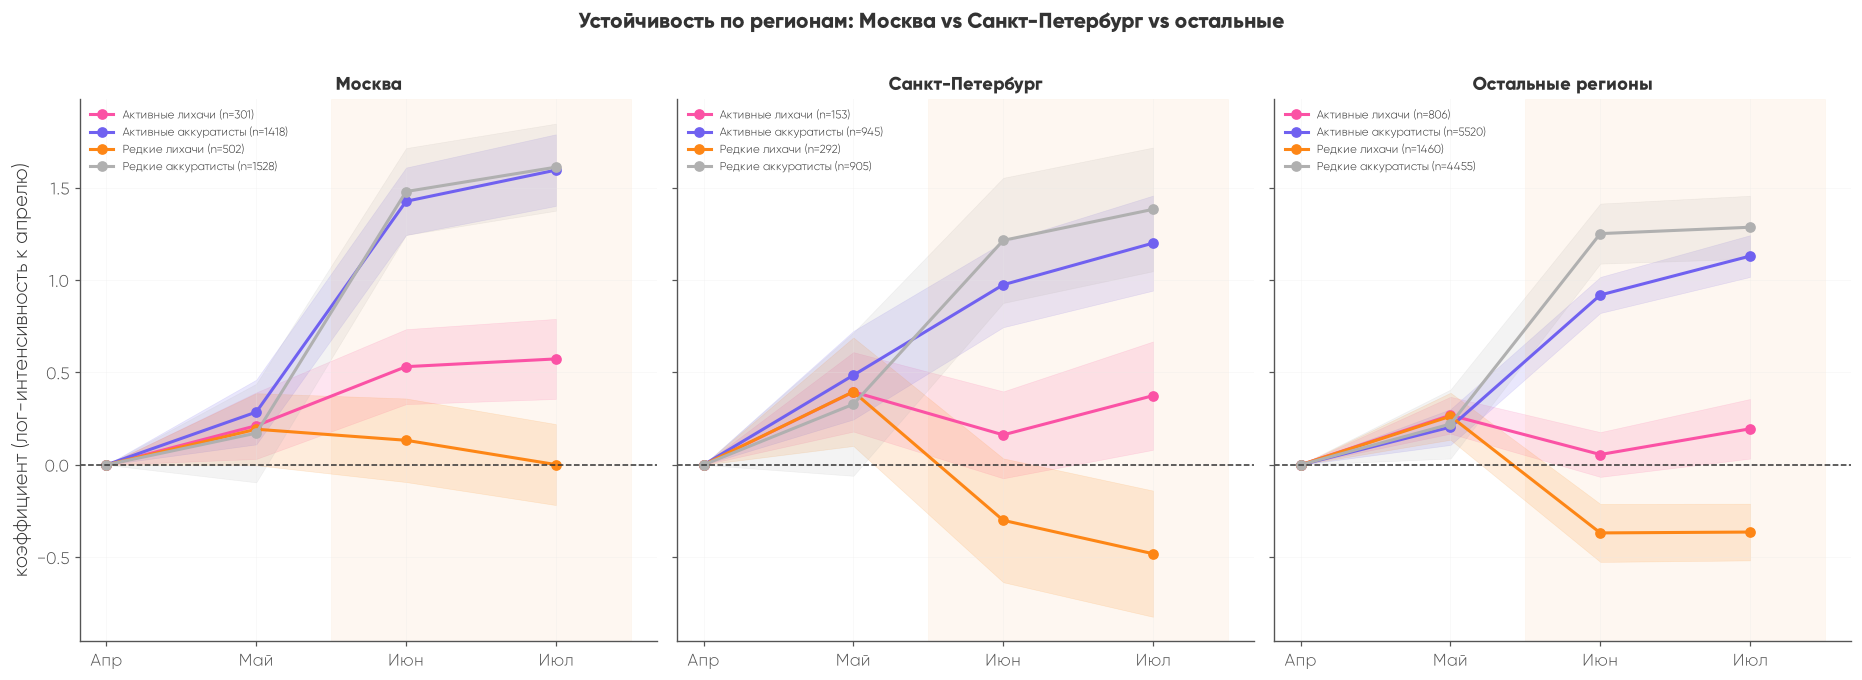

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

# ================== ДЕЛИМ НА 3 РЕГИОНАЛЬНЫЕ ГРУППЫ ==================
attrs = clients.drop_duplicates('client_id')[['client_id', 'kladr_code']].copy()
attrs['region_group'] = np.where(attrs.kladr_code == 77, 'Москва',
                          np.where(attrs.kladr_code == 78, 'Санкт-Петербург', 'Остальные регионы'))

panel = panel.merge(attrs[['client_id', 'region_group']], on='client_id', how='left')

# ================== ТА ЖЕ МОДЕЛЬ: своя база для каждой категории, отдельно по региональной группе ==================
order = ['Активные лихачи', 'Активные аккуратисты', 'Редкие лихачи', 'Редкие аккуратисты']
region_groups = ['Москва', 'Санкт-Петербург', 'Остальные регионы']

rows = []
for rg in region_groups:
    panel_rg = panel[panel.region_group == rg]
    for cat in order:
        sub = panel_rg[panel_rg.категория == cat]
        n_cl = sub.client_id.nunique()
        if n_cl < 30:
            continue
        m = smf.gee('fines ~ C(month)', groups='client_id', data=sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        for mth in [5, 6, 7]:
            key = f'C(month)[T.{mth}]'
            if key in t.index:
                rows.append({'регион_группа': rg, 'категория': cat, 'месяц': mth, 'n': n_cl,
                            'coef': t.loc[key, 'Coef.'], 'lo': t.loc[key, '[0.025'], 'hi': t.loc[key, '0.975]'],
                            'p': t.loc[key, 'P>|z|'], 'sig': t.loc[key, 'P>|z|'] < 0.05})

res_region = pd.DataFrame(rows)
print(res_region.round(3).to_string(index=False))

# ================== ГРАФИК: 3 панели рядом ==================
colors = {'Активные лихачи': PINK, 'Активные аккуратисты': PURPLE, 'Редкие лихачи': ORANGE, 'Редкие аккуратисты': GREY}
month_names = {4: 'Апр', 5: 'Май', 6: 'Июн', 7: 'Июл'}

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, rg in zip(axes, region_groups):
    sub_rg = res_region[res_region.регион_группа == rg]
    for cat in order:
        sub = sub_rg[sub_rg.категория == cat].sort_values('месяц')
        if sub.empty:
            continue
        x = [4] + sub.месяц.tolist()
        y = [0] + sub.coef.tolist()
        lo = [0] + sub.lo.tolist()
        hi = [0] + sub.hi.tolist()
        xt = [month_names[m] for m in x]
        n_cat = sub.n.iloc[0]
        ax.plot(xt, y, marker='o', ms=6, lw=2, color=colors[cat], label=f'{cat} (n={n_cat})')
        ax.fill_between(xt, lo, hi, color=colors[cat], alpha=.15)
    ax.axhline(0, color=INK, lw=1, ls='--')
    ax.axvspan(1.5, 3.5, color=ORANGE, alpha=.06)
    ax.set_title(rg, fontweight='bold', fontsize=12)
    ax.legend(frameon=False, fontsize=7.5, loc='upper left')

axes[0].set_ylabel('коэффициент (лог-интенсивность к апрелю)')
fig.suptitle('Устойчивость по регионам: Москва vs Санкт-Петербург vs остальные', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('region_group_stability.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

In [16]:
# --- шаг 1: создаём region_group
attrs = clients.drop_duplicates('client_id')[['client_id', 'kladr_code']].copy()
attrs['region_group'] = np.where(attrs.kladr_code == 77, 'Москва',
                          np.where(attrs.kladr_code == 78, 'Санкт-Петербург', 'Остальные регионы'))

# --- шаг 2: мерджим в panel (в этой же ячейке!)
panel = panel.merge(attrs[['client_id', 'region_group']], on='client_id', how='left')

# --- шаг 3: проверка перед тем, как идти дальше
assert 'region_group' in panel.columns, 'мердж не сработал'
print('region_group добавлен, пропусков:', panel.region_group.isna().sum(), 'из', len(panel))
print(panel.region_group.value_counts())

# --- шаг 4: сама модель по регионам (продолжение того же кода)
order = ['Активные лихачи', 'Активные аккуратисты', 'Редкие лихачи', 'Редкие аккуратисты']
region_groups = ['Москва', 'Санкт-Петербург', 'Остальные регионы']

rows = []
for rg in region_groups:
    panel_rg = panel[panel.region_group == rg]
    for cat in order:
        sub = panel_rg[panel_rg.категория == cat]
        n_cl = sub.client_id.nunique()
        if n_cl < 30:
            continue
        m = smf.gee('fines ~ C(month)', groups='client_id', data=sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        for mth in [5, 6, 7]:
            key = f'C(month)[T.{mth}]'
            if key in t.index:
                rows.append({'регион_группа': rg, 'категория': cat, 'месяц': mth, 'n': n_cl,
                            'coef': t.loc[key, 'Coef.'], 'lo': t.loc[key, '[0.025'], 'hi': t.loc[key, '0.975]'],
                            'p': t.loc[key, 'P>|z|'], 'sig': t.loc[key, 'P>|z|'] < 0.05})

res_region = pd.DataFrame(rows)
print(res_region.round(3).to_string(index=False))

AssertionError: мердж не сработал

In [ ]:
# ================== МОДЕЛЬ: своя база для каждой категории, отдельно по региональной группе ==================
order = ['Активные лихачи', 'Активные аккуратисты', 'Редкие лихачи', 'Редкие аккуратисты']
region_groups = ['Москва', 'Санкт-Петербург', 'Остальные регионы']

rows = []
for rg in region_groups:
    panel_rg = panel[panel.region_group == rg]
    for cat in order:
        sub = panel_rg[panel_rg.категория == cat]
        n_cl = sub.client_id.nunique()
        if n_cl < 30:
            continue
        m = smf.gee('fines ~ C(month)', groups='client_id', data=sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        for mth in [5, 6, 7]:
            key = f'C(month)[T.{mth}]'
            if key in t.index:
                rows.append({'регион_группа': rg, 'категория': cat, 'месяц': mth, 'n': n_cl,
                            'coef': t.loc[key, 'Coef.'], 'lo': t.loc[key, '[0.025'], 'hi': t.loc[key, '0.975]'],
                            'p': t.loc[key, 'P>|z|'], 'sig': t.loc[key, 'P>|z|'] < 0.05})

res_region = pd.DataFrame(rows)
print(res_region.round(3).to_string(index=False))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'
GREEN, RED = '#1D8348', '#C0392B'

order = ['Активные лихачи', 'Активные аккуратисты', 'Редкие лихачи', 'Редкие аккуратисты']
region_groups = ['Москва', 'Санкт-Петербург', 'Остальные регионы']

wide_rows = []
for rg in region_groups:
    for cat in order:
        row = {'Регион': rg, 'Категория': cat}
        for mth in [5, 6, 7]:
            cell = res_region[(res_region.регион_группа == rg) & (res_region.категория == cat) & (res_region.месяц == mth)]
            if len(cell):
                row[f'm{mth}'] = f"{cell.coef.iloc[0]:+.2f}\np={cell.p.iloc[0]:.3f}"
                row[f'm{mth}_sig'] = cell.sig.iloc[0]
        wide_rows.append(row)

wr = pd.DataFrame(wide_rows)
col_labels = ['Регион', 'Категория', 'Май', 'Июнь', 'Июль']

fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')
ax.set_title('По регионам, месяцы сгруппированы в столбцы\nзелёный = значимо (p<0.05), красный = нет',
             fontsize=13, fontweight='bold', pad=14)

cell_text = wr[['Регион', 'Категория', 'm5', 'm6', 'm7']].values.tolist()
prev_region = None
for row in cell_text:
    if row[0] == prev_region:
        row[0] = ''
    else:
        prev_region = row[0]

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center',
                 colWidths=[0.14, 0.24, 0.20, 0.20, 0.20])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.1)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(INK)
    table[(0, j)].set_text_props(color=WHITE, fontweight='bold')

for i, row in wr.iterrows():
    for j, mth in enumerate([5, 6, 7]):
        sig = row.get(f'm{mth}_sig')
        cell = table[(i + 1, j + 2)]
        if sig is None:
            cell.set_facecolor('#F0F0F0')
        elif sig:
            cell.set_facecolor('#D6F5E3'); cell.set_text_props(color=GREEN, fontweight='bold')
        else:
            cell.set_facecolor('#FBDCDC'); cell.set_text_props(color=RED, fontweight='bold')
    table[(i + 1, 0)].set_text_props(fontweight='bold')
    table[(i + 1, 1)].set_text_props(ha='left')

for idx in [4, 8]:
    for j in range(len(col_labels)):
        table[(idx + 1, j)].set_edgecolor(INK)
        table[(idx + 1, j)].set_linewidth(1.8)

plt.tight_layout()
plt.savefig('region_grouped_by_month.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

# гавнокод

In [53]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson

# ================== ПАНЕЛЬ: клиент x месяц, апрель-АВГУСТ ==================
fuel_c = fuel[(fuel.order_fuel_volume > 0) & (fuel.order_fuel_volume <= 100) &
             (fuel.order_fuel_price_1liter.between(40, 150))]
fuel_c = fuel_c[fuel_c.order_datetime.between('2026-04-01', '2026-08-31')].copy()
fuel_c['month'] = fuel_c.order_datetime.dt.month
liters_cm = fuel_c.groupby(['client_id', 'month']).order_fuel_volume.sum().rename('liters').reset_index()

fines_w = fines[fines.bill_offence_date.between('2026-04-01', '2026-08-31')].copy()
fines_w['month'] = fines_w.bill_offence_date.dt.month
fines_cm = fines_w.groupby(['client_id', 'month']).size().rename('fines').reset_index()

ids = d.client_id.unique()
grid = pd.MultiIndex.from_product([ids, [4, 5, 6, 7, 8]], names=['client_id', 'month']).to_frame(index=False)
panel = (grid.merge(liters_cm, on=['client_id', 'month'], how='left')
             .merge(fines_cm, on=['client_id', 'month'], how='left'))
panel[['liters', 'fines']] = panel[['liters', 'fines']].fillna(0)
panel = panel.merge(d[['client_id', 'категория']], on='client_id', how='left')
panel = panel[panel.liters > 0].copy()
panel['log_liters'] = np.log(panel.liters)

# ================== ТЕСТ: GEE ==================
model = smf.gee('fines ~ C(категория) * C(month)', groups='client_id', data=panel,
                family=Poisson(), cov_struct=Exchangeable(), offset=panel.log_liters)
res = model.fit()
t = res.summary2().tables[1]

# ================== ТАБЛИЦА СТАТЗНАЧИМОСТИ ==================
rows = []
for cat in ['Активные лихачи', 'Редкие лихачи', 'Редкие аккуратисты']:
    for m in [5, 6, 7, 8]:
        key = f'C(категория)[T.{cat}]:C(month)[T.{m}]'
        if key in t.index:
            rows.append({'категория': cat, 'месяц': m,
                        'coef': t.loc[key, 'Coef.'], 'p': t.loc[key, 'P>|z|'],
                        'значимо (p<0.05)': t.loc[key, 'P>|z|'] < 0.05})

sig_table = pd.DataFrame(rows)
print('=== Коэффициенты ===')
print(sig_table.pivot(index='категория', columns='месяц', values='coef').round(4))
print('\n=== p-values ===')
print(sig_table.pivot(index='категория', columns='месяц', values='p').round(4))
print('\n=== Значимость ===')
print(sig_table.pivot(index='категория', columns='месяц', values='значимо (p<0.05)'))

=== Коэффициенты ===
месяц                    5       6       7       8
категория                                         
Активные лихачи     0.0087 -0.8500 -0.9567 -1.1018
Редкие аккуратисты -0.0309  0.2925  0.1516  0.2276
Редкие лихачи      -0.0082 -1.2923 -1.5618 -1.6480

=== p-values ===
месяц                    5       6       7       8
категория                                         
Активные лихачи     0.8846  0.0000  0.0000  0.0000
Редкие аккуратисты  0.7314  0.0003  0.0714  0.0115
Редкие лихачи       0.9003  0.0000  0.0000  0.0000

=== Значимость ===
месяц                   5     6      7     8
категория                                   
Активные лихачи     False  True   True  True
Редкие аккуратисты  False  True  False  True
Редкие лихачи       False  True   True  True


/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])


In [55]:
# ================== ДОМЁРЖИВАЕМ АТРИБУТЫ КЛИЕНТА В PANEL ==================
AGE_MAP = {'A00': 'до 20 лет', 'A20': '21-40 лет', 'A40': '41-60 лет', 'A60': 'старше 60 лет'}
attrs = clients.drop_duplicates('client_id')[['client_id', 'gender', 'age_type_code', 'price', 'kladr_code']].copy()
attrs['возраст'] = attrs.age_type_code.map(AGE_MAP)

KLADR = {77: 'Москва', 50: 'Московская обл.', 78: 'Санкт-Петербург', 16: 'Татарстан',
         66: 'Свердловская обл.', 54: 'Новосибирская обл.', 47: 'Ленинградская обл.',
         52: 'Нижегородская обл.', 23: 'Краснодарский край', 63: 'Самарская обл.',
         74: 'Челябинская обл.', 42: 'Кемеровская обл.', 72: 'Тюменская обл.',
         2: 'Башкортостан', 24: 'Красноярский край', 55: 'Омская обл.'}
attrs['region'] = attrs.kladr_code.map(KLADR)

fu_reg = fuel_c.merge(attrs[['client_id', 'region']], on='client_id')
pre = fu_reg[fu_reg.month <= 5]
post = fu_reg[fu_reg.month >= 6]
shock = ((post.groupby('region').order_fuel_price_1liter.quantile(.95) /
         pre.groupby('region').order_fuel_price_1liter.quantile(.95) - 1) * 100).rename('shock')
attrs = attrs.merge(shock, on='region', how='left')
attrs['high_shock'] = attrs.shock >= shock.median()

panel = panel.merge(attrs[['client_id', 'gender', 'возраст', 'price', 'high_shock']], on='client_id', how='left')
print('колонки panel после мерджа:', panel.columns.tolist())
assert 'price' in panel.columns, 'price не подтянулся — проверь client_id на совпадение типов'

колонки panel после мерджа: ['client_id', 'month', 'liters', 'fines', 'категория', 'log_liters', 'gender', 'возраст', 'price', 'high_shock']


/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])
/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])
/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])
/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwarg

             подвыборка      n  АЛ_6_coef  АЛ_6_p  АЛ_6_sig  АЛ_7_coef  АЛ_7_p  АЛ_7_sig  АЛ_8_coef  АЛ_8_p  АЛ_8_sig  РЛ_6_coef  РЛ_6_p  РЛ_6_sig  РЛ_7_coef  РЛ_7_p  РЛ_7_sig  РЛ_8_coef  РЛ_8_p  РЛ_8_sig  РА_6_coef  \
0           Вся выборка  18285    -0.8500   0.000      True    -0.9567  0.0000      True    -1.1018  0.0000      True    -1.2923  0.0000      True    -1.5618  0.0000      True    -1.6480  0.0000      True     0.2925   
1                Пол: М  14834    -0.8054   0.000      True    -0.9488  0.0000      True    -1.1081  0.0000      True    -1.2584  0.0000      True    -1.5579  0.0000      True    -1.6523  0.0000      True     0.3222   
2                Пол: Ж   3429    -1.0622   0.000      True    -1.0061  0.0000      True    -1.1065  0.0000      True    -1.3611  0.0000      True    -1.5215  0.0000      True    -1.5959  0.0000      True     0.1862   
3         Возраст 21-40  10617    -0.8304   0.000      True    -0.9528  0.0000      True    -1.1140  0.0000      True    -1.

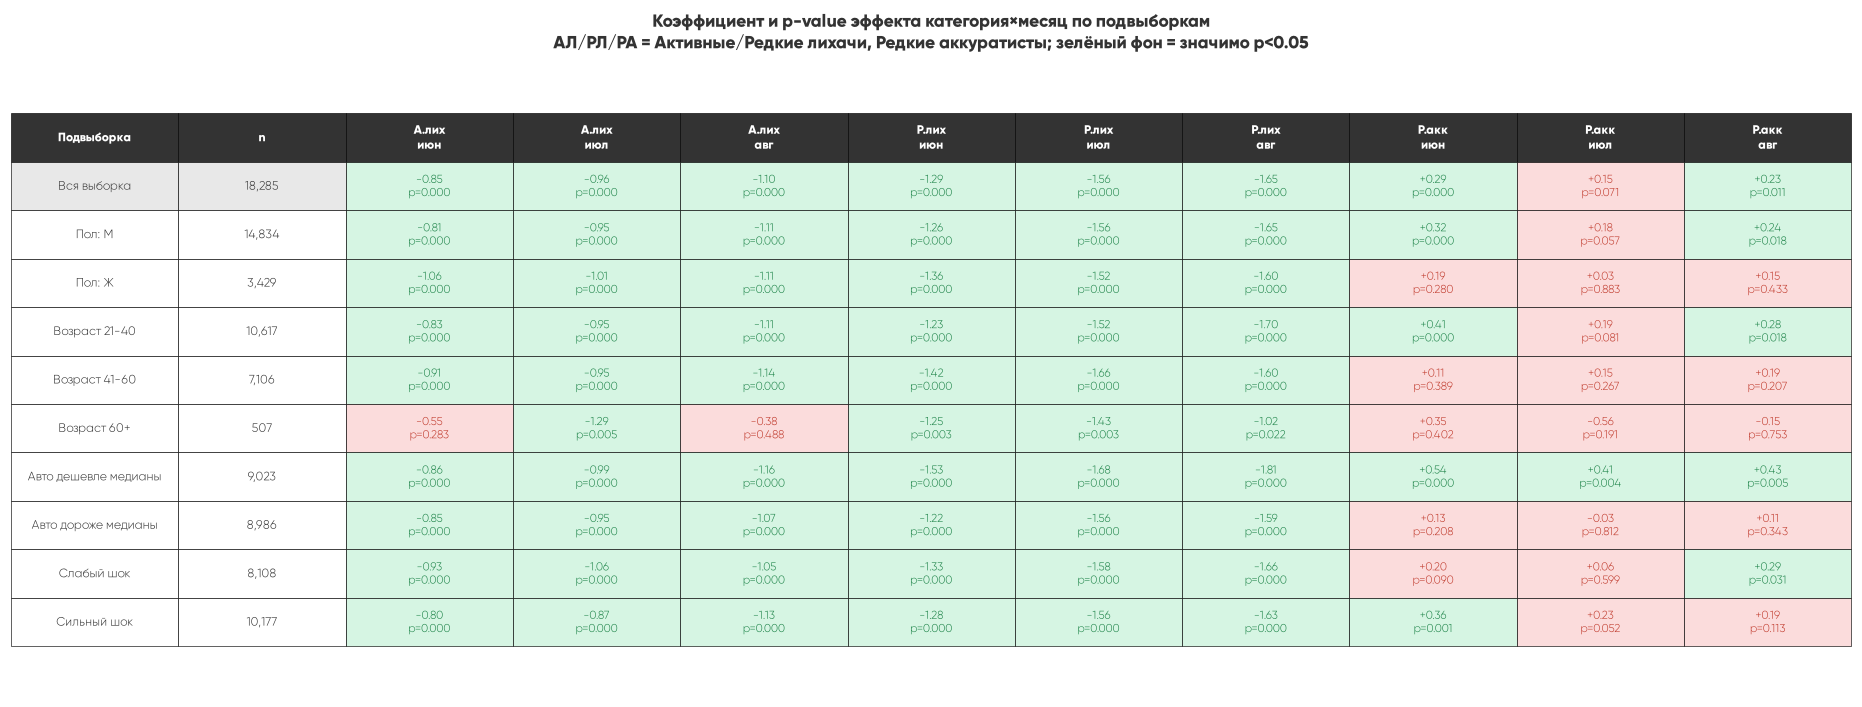

In [57]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson
import matplotlib.pyplot as plt

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

# ================== ФУНКЦИЯ: коэффициент + p-value по всем месяцам для одной подвыборки ==================
def get_sig_row(panel_sub, label):
    n_cl = panel_sub.client_id.nunique()
    if n_cl < 500:
        return None
    try:
        m = smf.gee('fines ~ C(категория) * C(month)', groups='client_id', data=panel_sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=panel_sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        row = {'подвыборка': label, 'n': n_cl}
        for cat, catshort in [('Активные лихачи', 'АЛ'), ('Редкие лихачи', 'РЛ'), ('Редкие аккуратисты', 'РА')]:
            for mth in [6, 7, 8]:
                key = f'C(категория)[T.{cat}]:C(month)[T.{mth}]'
                if key in t.index:
                    row[f'{catshort}_{mth}_coef'] = t.loc[key, 'Coef.']
                    row[f'{catshort}_{mth}_p'] = t.loc[key, 'P>|z|']
                    row[f'{catshort}_{mth}_sig'] = t.loc[key, 'P>|z|'] < 0.05
        return row
    except Exception:
        return None

# ================== ЗАПУСК ПО ВСЕМ ПОДГРУППАМ ==================
med_price = panel.price.median()
subs = [
    (panel, 'Вся выборка'),
    (panel[panel.gender == 'M'], 'Пол: М'),
    (panel[panel.gender == 'F'], 'Пол: Ж'),
    (panel[panel.возраст == '21-40 лет'], 'Возраст 21-40'),
    (panel[panel.возраст == '41-60 лет'], 'Возраст 41-60'),
    (panel[panel.возраст == 'старше 60 лет'], 'Возраст 60+'),
    (panel[panel.price < med_price], 'Авто дешевле медианы'),
    (panel[panel.price >= med_price], 'Авто дороже медианы'),
    (panel[panel.high_shock == False], 'Слабый шок'),
    (panel[panel.high_shock == True], 'Сильный шок'),
]
rows = [get_sig_row(p, l) for p, l in subs]
res = pd.DataFrame([r for r in rows if r is not None])
print(res.round(4))

# ================== ВИЗУАЛЬНАЯ ТАБЛИЦА: коэффициент + p-value в каждой ячейке ==================
cats_short = ['АЛ', 'РЛ', 'РА']
months = [6, 7, 8]
cols = [f'{c}_{m}' for c in cats_short for m in months]

fig, ax = plt.subplots(figsize=(17, 6.5))
ax.axis('off')
ax.set_title('Коэффициент и p-value эффекта категория×месяц по подвыборкам\n'
             'АЛ/РЛ/РА = Активные/Редкие лихачи, Редкие аккуратисты; зелёный фон = значимо p<0.05',
             fontsize=11.5, fontweight='bold', pad=10)

col_labels = ['Подвыборка', 'n'] + [f'{c}\n{m}' for c in ['А.лих', 'Р.лих', 'Р.акк'] for m in ['июн', 'июл', 'авг']]

cell_text = []
for _, row in res.iterrows():
    line = [row['подвыборка'], f"{row['n']:,}"]
    for c in cols:
        coef = row.get(f'{c}_coef', np.nan)
        p = row.get(f'{c}_p', np.nan)
        line.append(f'{coef:+.2f}\np={p:.3f}' if pd.notna(coef) else '—')
    cell_text.append(line)

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.3)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(INK)
    table[(0, j)].set_text_props(color=WHITE, fontweight='bold', fontsize=8)

for i, row in res.iterrows():
    for j, c in enumerate(cols):
        sig = row.get(f'{c}_sig', False)
        cell = table[(i + 1, j + 2)]
        cell.set_facecolor('#D6F5E3' if sig else '#FBDCDC')
        cell.set_text_props(color='#1D8348' if sig else '#C0392B', fontsize=7.5)
    if i == 0:
        table[(i + 1, 0)].set_facecolor('#E8E8E8')
        table[(i + 1, 1)].set_facecolor('#E8E8E8')

plt.tight_layout()
plt.savefig('sig_summary_with_pvalues.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

In [60]:
# --- регион (если ещё не был домержен в panel)
attrs_region = clients.drop_duplicates('client_id')[['client_id', 'kladr_code']].copy()
KLADR = {77: 'Москва', 50: 'Московская обл.', 78: 'Санкт-Петербург', 16: 'Татарстан',
         66: 'Свердловская обл.', 54: 'Новосибирская обл.', 47: 'Ленинградская обл.',
         52: 'Нижегородская обл.', 23: 'Краснодарский край', 63: 'Самарская обл.',
         74: 'Челябинская обл.', 42: 'Кемеровская обл.', 72: 'Тюменская обл.',
         2: 'Башкортостан', 24: 'Красноярский край', 55: 'Омская обл.'}
attrs_region['region'] = attrs_region.kladr_code.map(KLADR)

if 'region' not in panel.columns:
    panel = panel.merge(attrs_region[['client_id', 'region']], on='client_id', how='left')

print('клиентов по регионам:')
print(panel.groupby('region').client_id.nunique().sort_values(ascending=False))

# ================== ФУНКЦИЯ ПОДГОНКИ GEE НА РЕГИОНЕ ==================
def get_sig_row(panel_sub, label, min_n=200):
    n_cl = panel_sub.client_id.nunique()
    if n_cl < min_n:
        return {'регион': label, 'n': n_cl, 'статус': 'мало данных'}
    try:
        m = smf.gee('fines ~ C(категория) * C(month)', groups='client_id', data=panel_sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=panel_sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        row = {'регион': label, 'n': n_cl, 'статус': 'ok'}
        for cat, catshort in [('Активные лихачи', 'АЛ'), ('Редкие лихачи', 'РЛ'), ('Редкие аккуратисты', 'РА')]:
            for mth in [6, 7, 8]:
                key = f'C(категория)[T.{cat}]:C(month)[T.{mth}]'
                if key in t.index:
                    row[f'{catshort}_{mth}_sig'] = t.loc[key, 'P>|z|'] < 0.05
                    row[f'{catshort}_{mth}_p'] = t.loc[key, 'P>|z|']
        return row
    except Exception as e:
        return {'регион': label, 'n': n_cl, 'статус': f'ошибка: {e}'}

# ================== ЗАПУСК ПО ВСЕМ РЕГИОНАМ (порог снижен до 200, включая Башкортостан) ==================
regions = panel.region.dropna().unique()
rows = [get_sig_row(panel[panel.region == reg], reg) for reg in regions]
res = pd.DataFrame(rows).sort_values('n', ascending=False)
print(res[['регион', 'n', 'статус']])

клиентов по регионам:
region
Москва                3749
Московская обл.       2508
Санкт-Петербург       2295
Свердловская обл.     1756
Татарстан             1417
Нижегородская обл.    1085
Челябинская обл.      1057
Новосибирская обл.     884
Ленинградская обл.     657
Краснодарский край     517
Красноярский край      513
Кемеровская обл.       494
Самарская обл.         398
Омская обл.            383
Тюменская обл.         343
Башкортостан           229
Name: client_id, dtype: int64


/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])
/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])
/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])
/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwarg

                регион     n статус
1               Москва  3749     ok
0      Московская обл.  2508     ok
5      Санкт-Петербург  2295     ok
4    Свердловская обл.  1756     ok
12           Татарстан  1417     ok
9   Нижегородская обл.  1085     ok
2     Челябинская обл.  1057     ok
8   Новосибирская обл.   884     ok
11  Ленинградская обл.   657     ok
7   Краснодарский край   517     ok
3    Красноярский край   513     ok
10    Кемеровская обл.   494     ok
15      Самарская обл.   398     ok
14         Омская обл.   383     ok
13      Тюменская обл.   343     ok
6         Башкортостан   229     ok


/home/jupyter/venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:294: ValueWarning: unknown kwargs ['groups', 'time', 'weights', 'dep_data', 'update_dep', 'constraint', 'cov_struct']
  self._check_kwargs(kwargs, ["n_trials"])


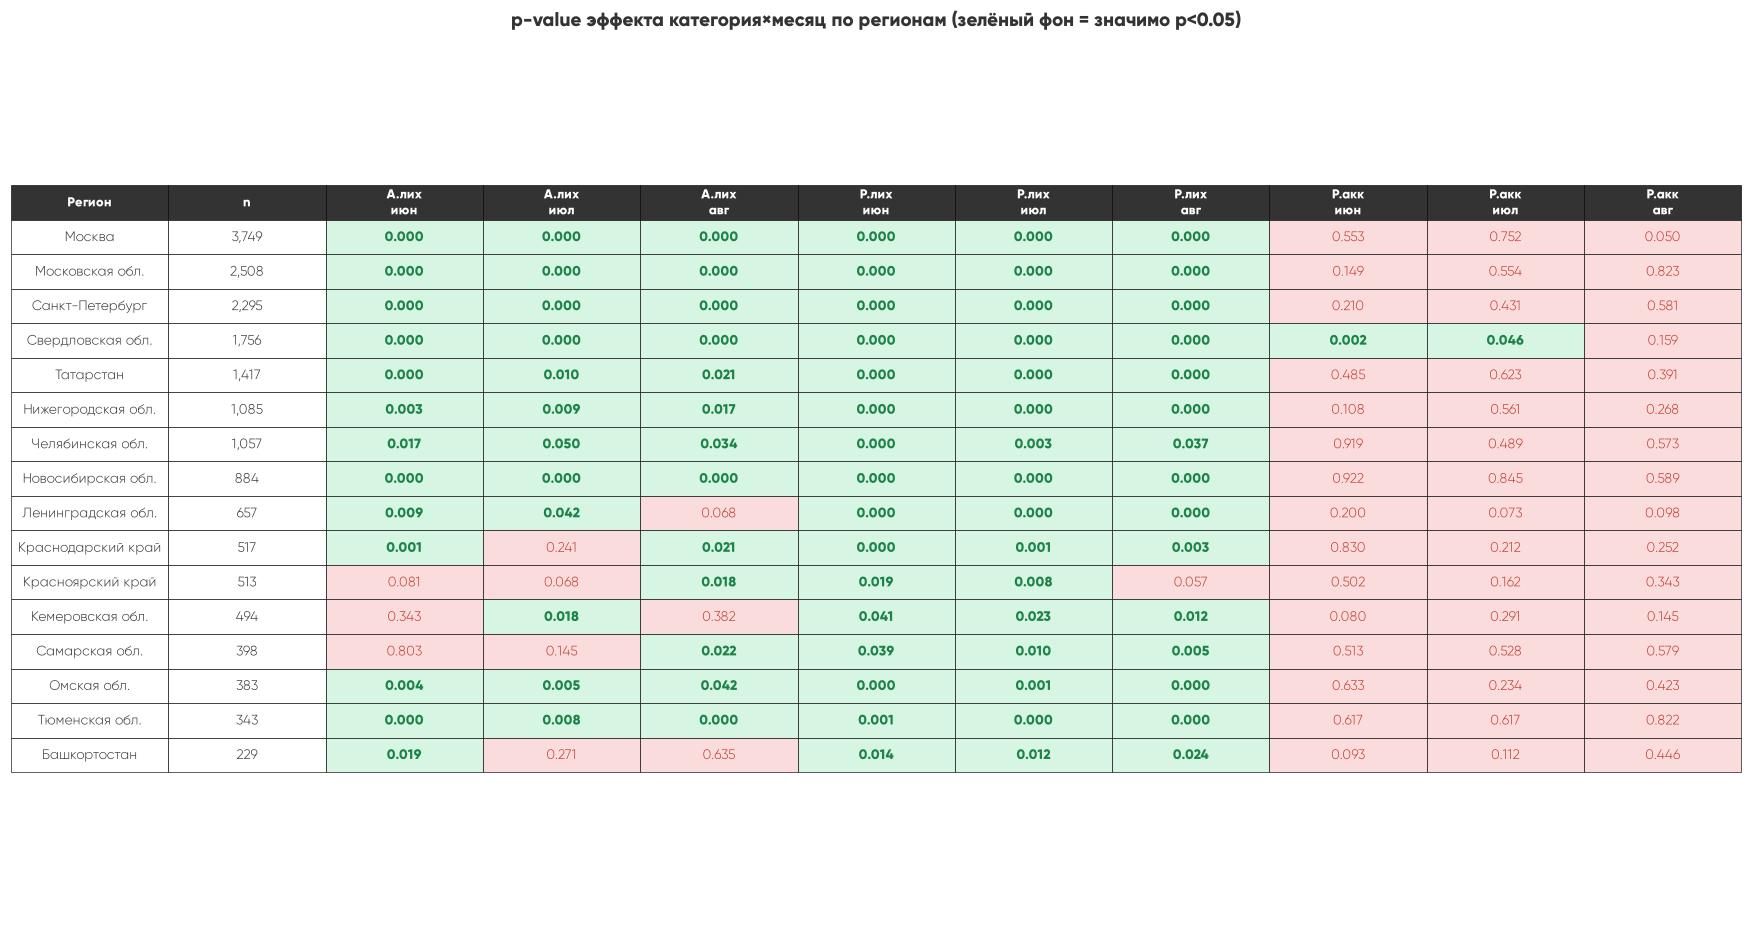

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

# ================== ПОДГОТОВКА ДАННЫХ ==================
res_ok = res[res.статус == 'ok'].sort_values('n', ascending=False).reset_index(drop=True)

cats_short = ['АЛ', 'РЛ', 'РА']
months = [6, 7, 8]
cols_sig = [f'{c}_{m}_sig' for c in cats_short for m in months]
cols_p = [f'{c}_{m}_p' for c in cats_short for m in months]

col_labels = ['Регион', 'n'] + [f'{c}\n{m}' for c in ['А.лих', 'Р.лих', 'Р.акк'] for m in ['июн', 'июл', 'авг']]

# ================== ТАБЛИЦА С P-VALUE ==================
fig, ax = plt.subplots(figsize=(16, 8.5))
ax.axis('off')
ax.set_title('p-value эффекта категория×месяц по регионам (зелёный фон = значимо p<0.05)',
             fontsize=12.5, fontweight='bold', pad=10)

cell_text = []
for _, row in res_ok.iterrows():
    line = [row['регион'], f"{row['n']:,}"]
    for c_p in cols_p:
        p = row.get(c_p, None)
        line.append(f'{p:.3f}' if pd.notna(p) else '—')
    cell_text.append(line)

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.55)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(INK)
    table[(0, j)].set_text_props(color=WHITE, fontweight='bold', fontsize=8.5)

for i, row in res_ok.iterrows():
    for j, (c_sig, c_p) in enumerate(zip(cols_sig, cols_p)):
        v = row.get(c_sig, None)
        cell = table[(i + 1, j + 2)]
        if v == True:
            cell.set_facecolor('#D6F5E3'); cell.set_text_props(color='#1D8348', fontweight='bold')
        elif v == False:
            cell.set_facecolor('#FBDCDC'); cell.set_text_props(color='#C0392B')
        else:
            cell.set_facecolor('#F0F0F0')

plt.tight_layout()
plt.savefig('sig_by_region_pvalues.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

                    подвыборка      n  АЛ_6_coef  АЛ_6_p  АЛ_6_sig  АЛ_7_coef  АЛ_7_p  АЛ_7_sig  АЛ_8_coef  АЛ_8_p  АЛ_8_sig  РЛ_6_coef  РЛ_6_p  РЛ_6_sig  РЛ_7_coef  РЛ_7_p  РЛ_7_sig  РЛ_8_coef  РЛ_8_p  РЛ_8_sig  \
0                  Вся выборка  18285    -0.8500  0.0000      True    -0.9567  0.0000      True    -1.1018  0.0000      True    -1.2923  0.0000      True    -1.5618  0.0000      True    -1.6480  0.0000      True   
1                       Пол: М  14834    -0.8054  0.0000      True    -0.9488  0.0000      True    -1.1081  0.0000      True    -1.2584  0.0000      True    -1.5579  0.0000      True    -1.6523  0.0000      True   
2                       Пол: Ж   3429    -1.0622  0.0000      True    -1.0061  0.0000      True    -1.1065  0.0000      True    -1.3611  0.0000      True    -1.5215  0.0000      True    -1.5959  0.0000      True   
3                Возраст 21-40  10617    -0.8304  0.0000      True    -0.9528  0.0000      True    -1.1140  0.0000      True    -1.2315  0.0

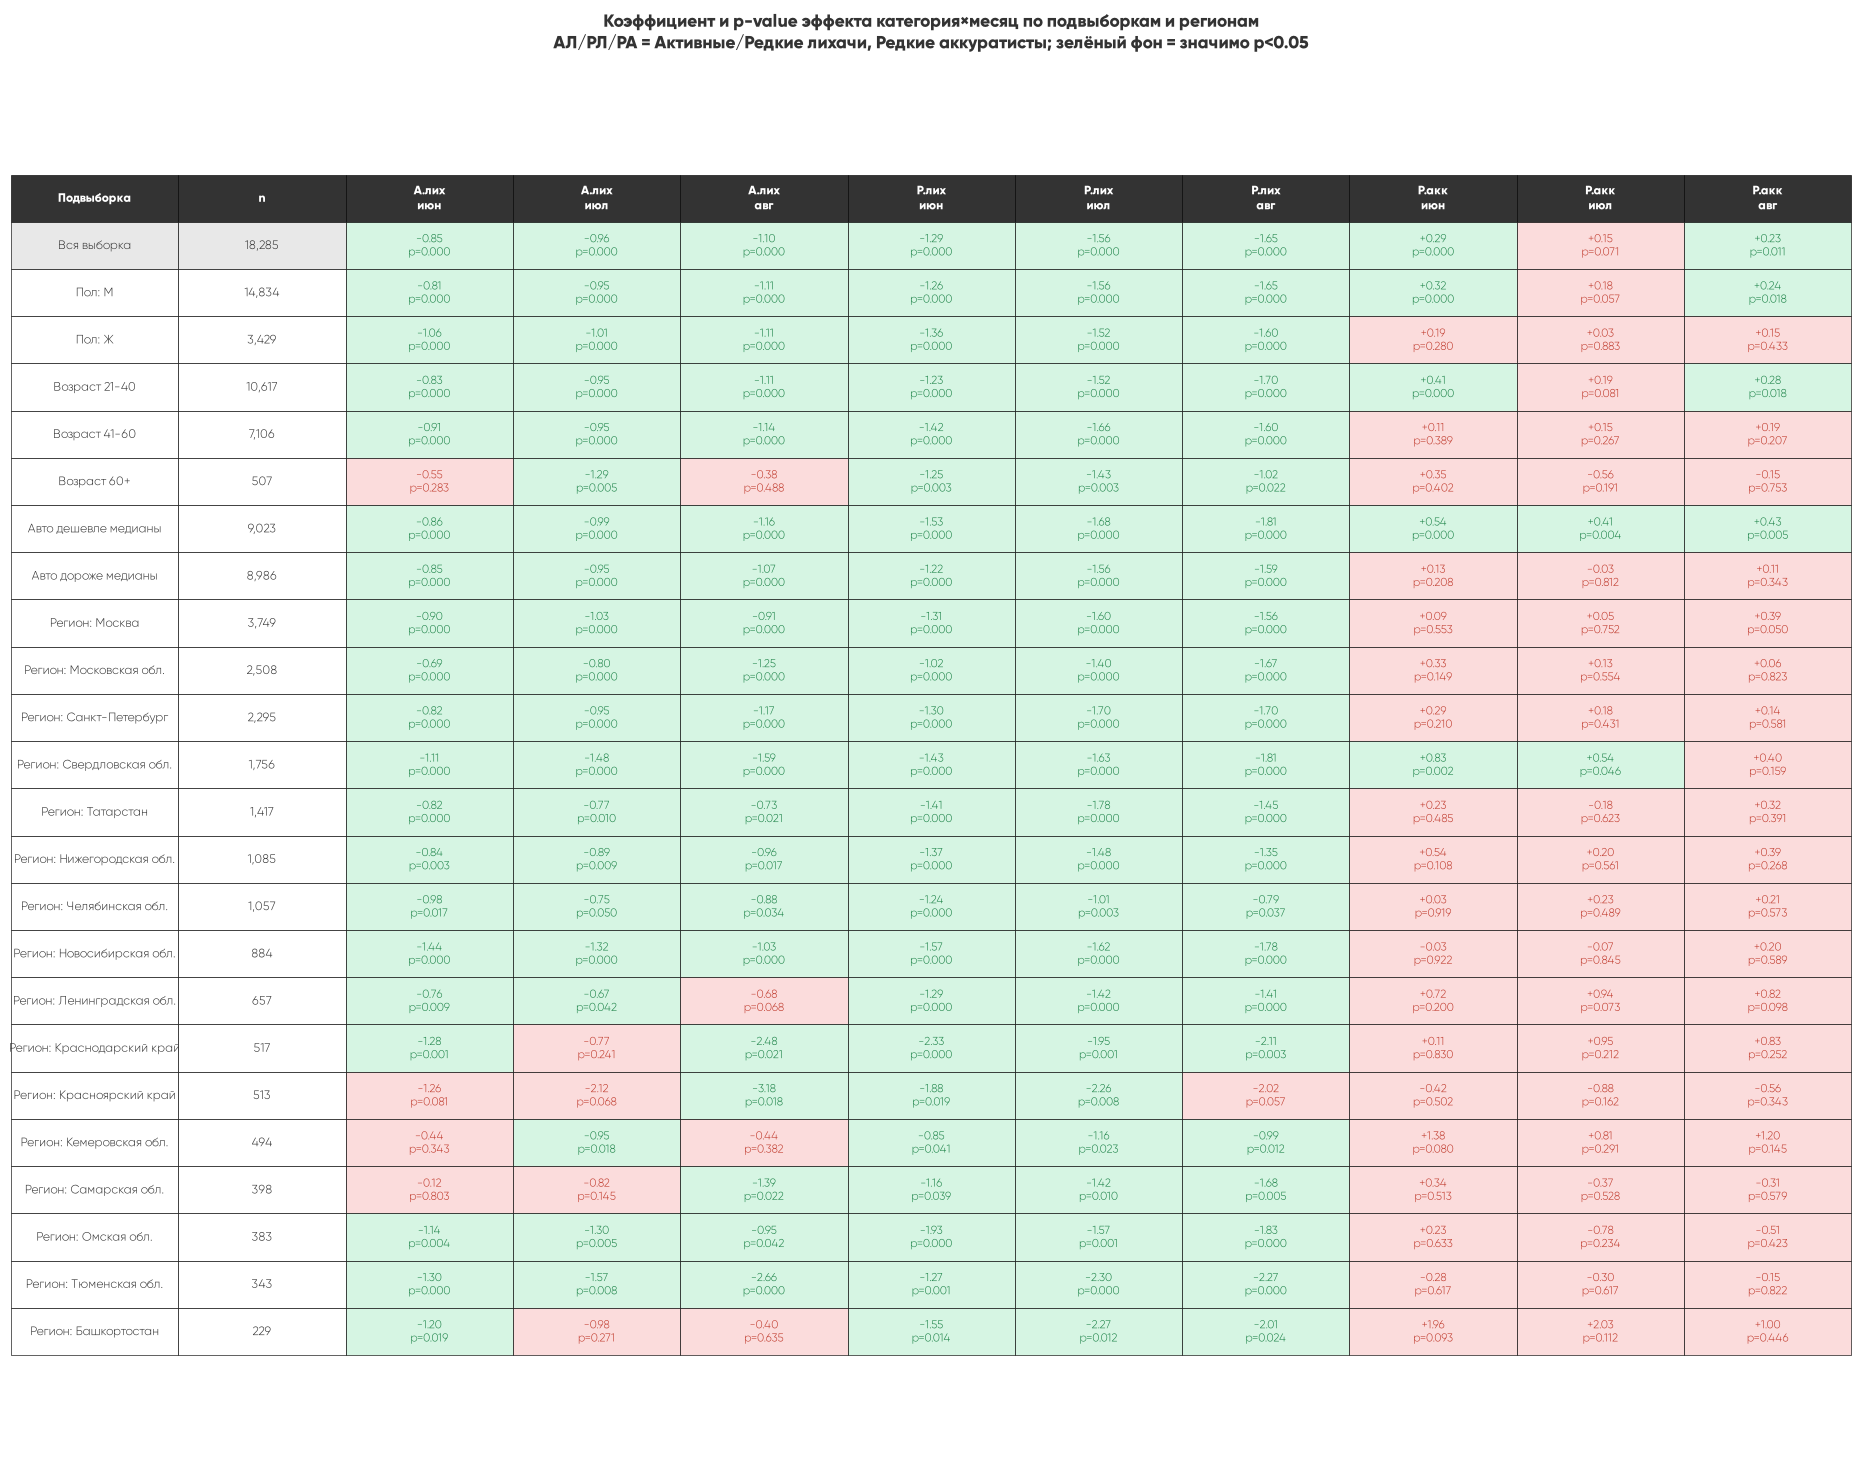

In [63]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

# ================== РЕГИОН (если ещё не домержен) ==================
KLADR = {
    77: 'Москва', 50: 'Московская обл.', 78: 'Санкт-Петербург', 16: 'Татарстан',
    66: 'Свердловская обл.', 54: 'Новосибирская обл.', 47: 'Ленинградская обл.',
    52: 'Нижегородская обл.', 23: 'Краснодарский край', 63: 'Самарская обл.',
    74: 'Челябинская обл.', 42: 'Кемеровская обл.', 72: 'Тюменская обл.',
    2: 'Башкортостан', 24: 'Красноярский край', 55: 'Омская обл.',
}
if 'region' not in panel.columns:
    attrs_region = clients.drop_duplicates('client_id')[['client_id', 'kladr_code']].copy()
    attrs_region['region'] = attrs_region.kladr_code.map(KLADR)
    panel = panel.merge(attrs_region[['client_id', 'region']], on='client_id', how='left')

# ================== ФУНКЦИЯ: коэффициент + p-value по всем месяцам для одной подвыборки ==================
def get_sig_row(panel_sub, label, min_n=200):
    n_cl = panel_sub.client_id.nunique()
    if n_cl < min_n:
        return None
    try:
        m = smf.gee('fines ~ C(категория) * C(month)', groups='client_id', data=panel_sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=panel_sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        row = {'подвыборка': label, 'n': n_cl}
        for cat, catshort in [('Активные лихачи', 'АЛ'), ('Редкие лихачи', 'РЛ'), ('Редкие аккуратисты', 'РА')]:
            for mth in [6, 7, 8]:
                key = f'C(категория)[T.{cat}]:C(month)[T.{mth}]'
                if key in t.index:
                    row[f'{catshort}_{mth}_coef'] = t.loc[key, 'Coef.']
                    row[f'{catshort}_{mth}_p'] = t.loc[key, 'P>|z|']
                    row[f'{catshort}_{mth}_sig'] = t.loc[key, 'P>|z|'] < 0.05
        return row
    except Exception:
        return None

# ================== ЗАПУСК: демография + цена (БЕЗ high_shock) ==================
med_price = panel.price.median()
subs = [
    (panel, 'Вся выборка'),
    (panel[panel.gender == 'M'], 'Пол: М'),
    (panel[panel.gender == 'F'], 'Пол: Ж'),
    (panel[panel.возраст == '21-40 лет'], 'Возраст 21-40'),
    (panel[panel.возраст == '41-60 лет'], 'Возраст 41-60'),
    (panel[panel.возраст == 'старше 60 лет'], 'Возраст 60+'),
    (panel[panel.price < med_price], 'Авто дешевле медианы'),
    (panel[panel.price >= med_price], 'Авто дороже медианы'),
]
rows = [get_sig_row(p, l) for p, l in subs]

# ================== ЗАПУСК: по каждому региону отдельно ==================
regions = panel.region.dropna().unique()
regions_sorted = panel.groupby('region').client_id.nunique().sort_values(ascending=False).index
rows += [get_sig_row(panel[panel.region == reg], f'Регион: {reg}') for reg in regions_sorted]

res = pd.DataFrame([r for r in rows if r is not None])
print(res.round(4))

# ================== ВИЗУАЛЬНАЯ ТАБЛИЦА: коэффициент + p-value в каждой ячейке ==================
cats_short = ['АЛ', 'РЛ', 'РА']
months = [6, 7, 8]
cols = [f'{c}_{m}' for c in cats_short for m in months]

fig, ax = plt.subplots(figsize=(17, 0.5 * len(res) + 1.5))
ax.axis('off')
ax.set_title('Коэффициент и p-value эффекта категория×месяц по подвыборкам и регионам\n'
             'АЛ/РЛ/РА = Активные/Редкие лихачи, Редкие аккуратисты; зелёный фон = значимо p<0.05',
             fontsize=11.5, fontweight='bold', pad=10)

col_labels = ['Подвыборка', 'n'] + [f'{c}\n{m}' for c in ['А.лих', 'Р.лих', 'Р.акк'] for m in ['июн', 'июл', 'авг']]

cell_text = []
for _, row in res.iterrows():
    line = [row['подвыборка'], f"{row['n']:,}"]
    for c in cols:
        coef = row.get(f'{c}_coef', np.nan)
        p = row.get(f'{c}_p', np.nan)
        line.append(f'{coef:+.2f}\np={p:.3f}' if pd.notna(coef) else '—')
    cell_text.append(line)

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.1)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(INK)
    table[(0, j)].set_text_props(color=WHITE, fontweight='bold', fontsize=8)

for i, row in res.iterrows():
    for j, c in enumerate(cols):
        sig = row.get(f'{c}_sig', False)
        cell = table[(i + 1, j + 2)]
        cell.set_facecolor('#D6F5E3' if sig else '#FBDCDC')
        cell.set_text_props(color='#1D8348' if sig else '#C0392B', fontsize=7.5)
    if i == 0:
        table[(i + 1, 0)].set_facecolor('#E8E8E8')
        table[(i + 1, 1)].set_facecolor('#E8E8E8')

plt.tight_layout()
plt.savefig('sig_summary_full.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()

                    подвыборка  n_total  АЛ_coef   АЛ_p  АЛ_n  АА_coef   АА_p  АА_n  РЛ_coef   РЛ_p  РЛ_n  РА_coef   РА_p  РА_n
0                  Вся выборка    18285   -0.030  0.417  1260    0.907  0.000  7883   -0.562  0.000  2254    1.119  0.000  6888
1                       Пол: М    14834   -0.015  0.707  1026    0.898  0.000  6496   -0.557  0.000  1804    1.117  0.000  5508
2                       Пол: Ж     3429   -0.104  0.262   232    0.954  0.000  1382   -0.560  0.000   444    1.135  0.000  1371
3                Возраст 21-40    10617   -0.009  0.837   862    0.919  0.000  4569   -0.493  0.000  1413    1.171  0.000  3773
4                Возраст 41-60     7106   -0.071  0.321   372    0.896  0.000  3071   -0.702  0.000   786    1.063  0.000  2877
5                  Возраст 60+      507    0.032  0.885    21    0.692  0.000   216   -0.842  0.000    46    0.718  0.002   224
6         Авто дешевле медианы     9023   -0.129  0.015   692    0.870  0.000  4601   -0.815  0.000   90

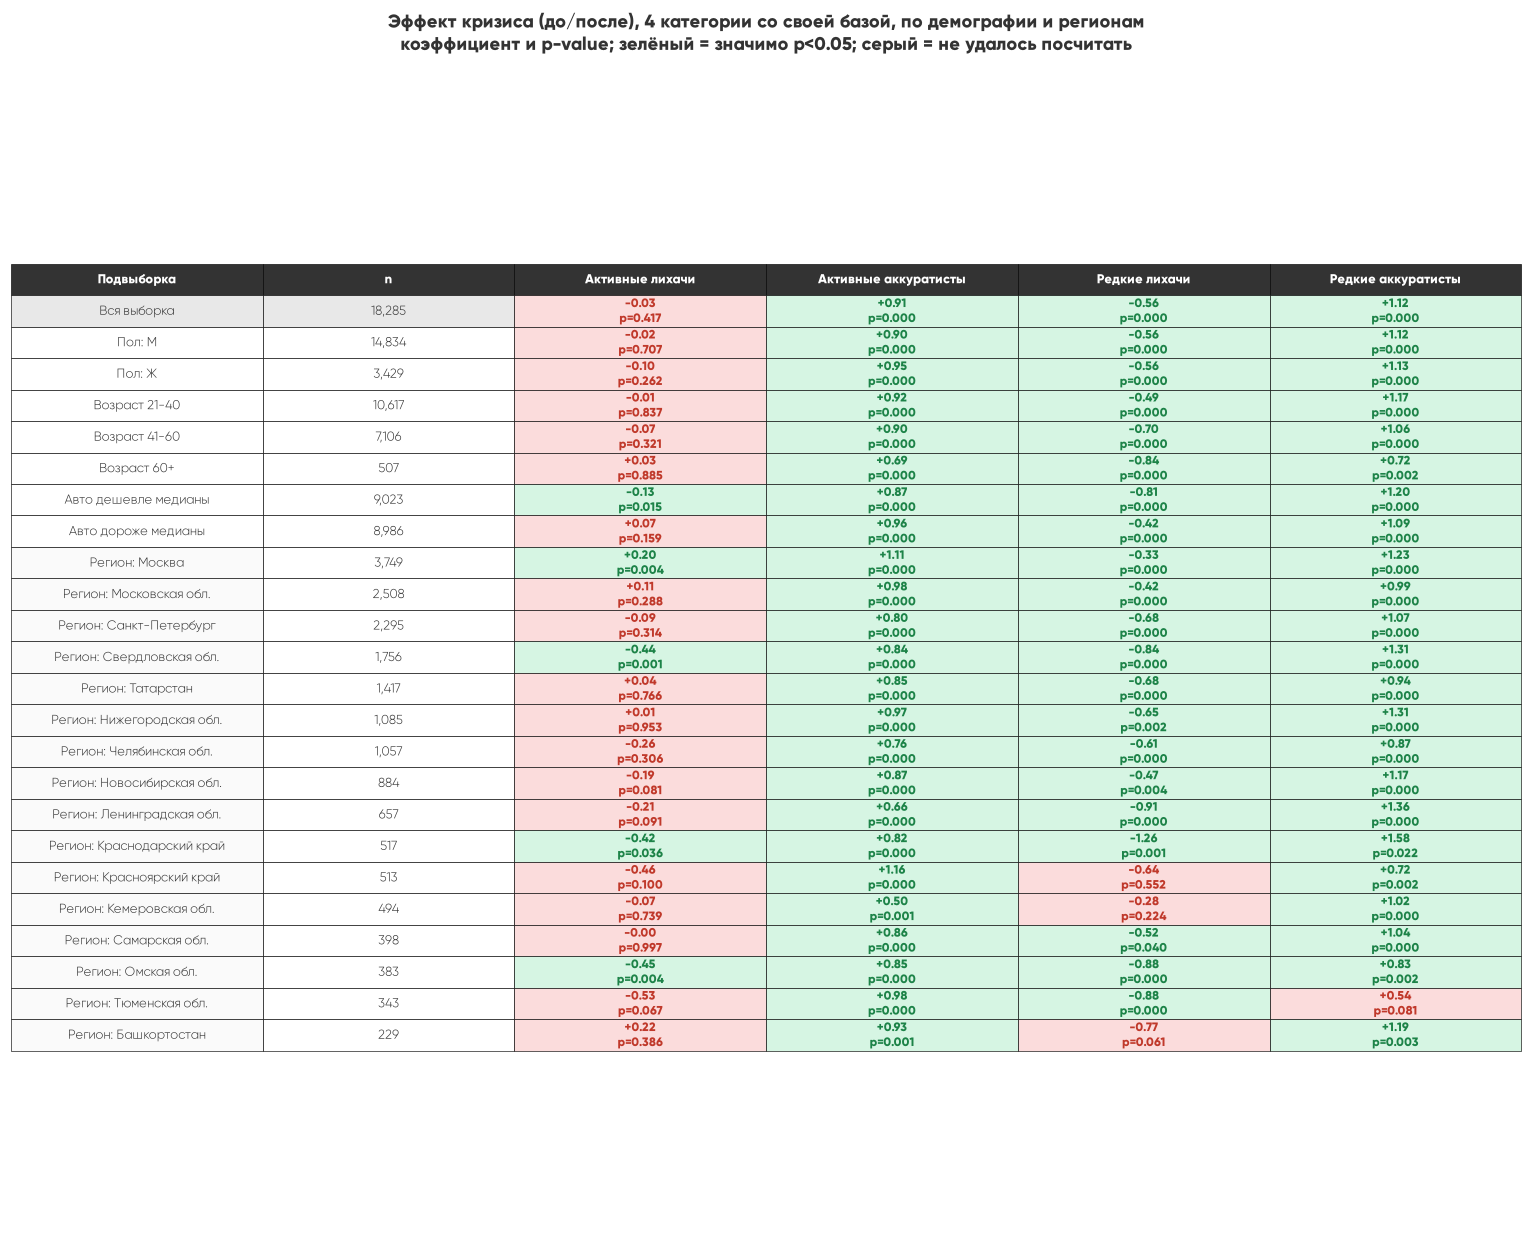

In [69]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PINK, ORANGE, PURPLE, WHITE, INK, MUTE, GREY = '#FB52A5', '#FD8616', '#7061F0', '#FFFFFF', '#333333', '#555555', '#B0B0B0'

# ================== ПОДГОТОВКА ==================
panel['post'] = (panel.month >= 6).astype(int)
med_price = panel.price.median()

order = ['Активные лихачи', 'Активные аккуратисты', 'Редкие лихачи', 'Редкие аккуратисты']
short = {'Активные лихачи': 'АЛ', 'Активные аккуратисты': 'АА', 'Редкие лихачи': 'РЛ', 'Редкие аккуратисты': 'РА'}

# ================== ФУНКЦИЯ: своя модель для ОДНОЙ категории (без референса, без порога по n) ==================
def fit_cat(panel_sub, cat):
    sub = panel_sub[panel_sub.категория == cat]
    n_cl = sub.client_id.nunique()
    try:
        m = smf.gee('fines ~ post', groups='client_id', data=sub,
                   family=Poisson(), cov_struct=Exchangeable(), offset=sub.log_liters)
        r = m.fit()
        t = r.summary2().tables[1]
        return {'coef': t.loc['post', 'Coef.'], 'p': t.loc['post', 'P>|z|'], 'n': n_cl}
    except Exception:
        return {'coef': np.nan, 'p': np.nan, 'n': n_cl}

# ================== ПОДВЫБОРКИ: демография + регионы ==================
subs = [
    (panel, 'Вся выборка'),
    (panel[panel.gender == 'M'], 'Пол: М'),
    (panel[panel.gender == 'F'], 'Пол: Ж'),
    (panel[panel.возраст == '21-40 лет'], 'Возраст 21-40'),
    (panel[panel.возраст == '41-60 лет'], 'Возраст 41-60'),
    (panel[panel.возраст == 'старше 60 лет'], 'Возраст 60+'),
    (panel[panel.price < med_price], 'Авто дешевле медианы'),
    (panel[panel.price >= med_price], 'Авто дороже медианы'),
]

regions_sorted = panel.groupby('region').client_id.nunique().sort_values(ascending=False).index
subs += [(panel[panel.region == reg], f'Регион: {reg}') for reg in regions_sorted]

# ================== ЗАПУСК ПО ВСЕМ ПОДВЫБОРКАМ, ВСЕМ 4 КАТЕГОРИЯМ ==================
rows = []
for sub_panel, label in subs:
    row = {'подвыборка': label, 'n_total': sub_panel.client_id.nunique()}
    for cat in order:
        res = fit_cat(sub_panel, cat)
        s = short[cat]
        row[f'{s}_coef'] = res['coef']
        row[f'{s}_p'] = res['p']
        row[f'{s}_n'] = res['n']
    rows.append(row)

res_all = pd.DataFrame(rows)
print(res_all.round(3))

# ================== ВИЗУАЛЬНАЯ ЕДИНАЯ ТАБЛИЦА ==================
order_short = ['АЛ', 'АА', 'РЛ', 'РА']
names = {'АЛ': 'Активные лихачи', 'АА': 'Активные аккуратисты', 'РЛ': 'Редкие лихачи', 'РА': 'Редкие аккуратисты'}
col_labels = ['Подвыборка', 'n'] + [names[s] for s in order_short]

fig, ax = plt.subplots(figsize=(14, 11.5))
ax.axis('off')
ax.set_title('Эффект кризиса (до/после), 4 категории со своей базой, по демографии и регионам\n'
             'коэффициент и p-value; зелёный = значимо p<0.05; серый = не удалось посчитать',
             fontsize=12, fontweight='bold', pad=12)

cell_text = []
for _, row in res_all.iterrows():
    line = [row['подвыборка'], f"{int(row['n_total']):,}"]
    for s in order_short:
        coef = row.get(f'{s}_coef'); p = row.get(f'{s}_p')
        line.append(f'{coef:+.2f}\np={p:.3f}' if pd.notna(coef) else '—')
    cell_text.append(line)

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.42)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(INK)
    table[(0, j)].set_text_props(color=WHITE, fontweight='bold')

for i, row in res_all.iterrows():
    for j, s in enumerate(order_short):
        coef = row.get(f'{s}_coef'); p = row.get(f'{s}_p')
        cell = table[(i + 1, j + 2)]
        if pd.isna(coef):
            cell.set_facecolor('#F0F0F0')
        elif p < 0.05:
            cell.set_facecolor('#D6F5E3'); cell.set_text_props(color='#1D8348', fontweight='bold', fontsize=8)
        else:
            cell.set_facecolor('#FBDCDC'); cell.set_text_props(color='#C0392B', fontweight='bold', fontsize=8)
    if row['подвыборка'] == 'Вся выборка':
        table[(i + 1, 0)].set_facecolor('#E8E8E8')
        table[(i + 1, 1)].set_facecolor('#E8E8E8')
    if str(row['подвыборка']).startswith('Регион:'):
        table[(i + 1, 0)].set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('four_cat_unified_table.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()